# Solemne I - Egresos Hospitalarios 2024
> Notebook adaptado para ejecucion local en **VSCode + Jupyter**.
> Requiere Python 3.10+, Java 11+, PySpark 3.5 y el archivo `EGRESOS_2024.xlsx` en la misma carpeta.
> Ver `requirements.txt` para instalar dependencias.

# Solemne I — Egresos Hospitalarios 2024  
## Fases 1, 2, 3 y 4: Preparación y modelado

**Problema:** preparar una base de egresos hospitalarios 2024 para un futuro modelo de clasificación binaria que permita distinguir entre pacientes que egresan vivos y pacientes que egresan fallecidos.

**Importante:** este notebook ahora incluye la **Fase 4 — Modelado**, con dos enfoques: Regresión Logística regularizada y Random Forest, ambos encapsulados en pipelines de Spark ML.

## 0. Configuracion del entorno local

Las dependencias se instalan con `pip install -r requirements.txt`.
Java 11 o superior debe estar instalado y disponible en el PATH.
PySpark detecta automaticamente `JAVA_HOME` si esta configurado en el sistema.

In [ ]:
# Verificacion del entorno local
# Si no instalaste las dependencias, ejecuta en terminal:
#   pip install -r requirements.txt

import subprocess, sys
result = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(result.stderr or result.stdout or "Java no encontrado en PATH")

for pkg in ["pyspark", "pandas", "numpy", "matplotlib", "seaborn", "openpyxl", "sklearn", "xgboost"]:
    try:
        __import__(pkg)
        print(f"OK: {pkg}")
    except ImportError:
        print(f"FALTA: {pkg} - ejecuta pip install -r requirements.txt")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.


In [ ]:
# ============================================================
# Librerías generales
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
# Configuracion de Spark (entorno local)

import os

# Si JAVA_HOME no esta configurado en el sistema, descomenta y ajusta:
# os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-11"  # Windows
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"  # Linux

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, trim, when, lit, count, sum as spark_sum,
    isnan, desc, regexp_replace, substring, length, log1p
)
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, Imputer
)

import multiprocessing
n_cores = multiprocessing.cpu_count()

spark = (
    SparkSession.builder
    .appName("SolemneI_Egresos_2024")
    .master(f"local[{n_cores}]")
    .config("spark.sql.shuffle.partitions", str(n_cores * 2))
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} iniciado con {n_cores} cores locales")
spark


#  FASE 1: Entendimiento del Negocio (Business Understanding)

## 1.1 Definición del Problema Real

Los egresos hospitalarios en Chile representan uno de los principales registros administrativos de salud del país, capturando cada alta médica ocurrida en establecimientos del **Sistema Nacional de Servicios de Salud (SNSS)** y del sector privado.

Un **egreso hospitalario** puede terminar de dos formas:
- **Vivo (código 1)**: el paciente es dado de alta en condiciones de vida.
- **Fallecido (código 2)**: el paciente muere durante su hospitalización.

Identificar *a priori* qué perfiles de paciente tienen mayor riesgo de fallecer durante su hospitalización tiene valor clínico y de gestión hospitalaria:
- Permite **priorizar recursos** de UCI y cuidados críticos.
- Apoya decisiones de **triaje y derivación** oportuna.
- Contribuye a políticas de salud pública orientadas a **reducir la mortalidad hospitalaria evitable**.

---

## 1.2 Objetivo Analítico

> **¿Qué se predice?**  
> La **condición de egreso** del paciente al momento del alta hospitalaria: si egresa **vivo** o **fallecido**.

> **¿Por qué es útil?**  
> Un modelo predictivo entrenado sobre variables demográficas (edad, sexo, previsión, región) y clínicas (diagnóstico CIE-10, días de estadía) puede ser integrado en sistemas de soporte a la decisión clínica para alertar tempranamente sobre pacientes en riesgo de muerte intrahospitalaria.

---

## 1.3 Pregunta de Negocio → Problema de Machine Learning

| Dimensión | Detalle |
|---|---|
| **Pregunta de negocio** | ¿Qué características del paciente y de su hospitalización predicen si egresará vivo o fallecido? |
| **Tipo de problema ML** | **Clasificación Binaria** |
| **Variable objetivo** | `CONDICION_EGRESO` → 0=Vivo, 1=Fallecido |
| **Variables predictoras** | Sexo, Grupo de edad, Región, Previsión, Diagnóstico principal (CIE-10), Días de estadía, Tipo de establecimiento |
| **Métrica principal** | AUC-ROC (dado el desbalance de clases esperado) |
| **Desafío esperado** | Alto desbalance de clases (mortalidad hospitalaria ~1-5%) |



In [ ]:
# ============================================================
# Definición del problema de negocio
# ============================================================

problema_negocio = {
    "contexto": "Análisis de egresos hospitalarios registrados durante el año 2024.",
    "objetivo": (
        "Preparar una base de datos para un futuro modelo de clasificación binaria "
        "que permita identificar la condición de egreso del paciente."
    ),
    "variable_objetivo_original": "CONDICION_EGRESO",
    "codificacion_objetivo": {
        "1": "Egreso vivo",
        "2": "Egreso fallecido"
    },
    "label_modelo": {
        "0.0": "Egreso vivo",
        "1.0": "Egreso fallecido"
    },
    "alcance_notebook": "Solo Fases 1, 2 y 3. No se entrenan modelos predictivos.",
    "nota_metodologica": (
        "DIAS_ESTADA se analiza descriptivamente. Por defecto no se usa como predictor, "
        "porque puede no estar disponible al inicio de una hospitalización y podría generar fuga temporal."
    )
}

for clave, valor in problema_negocio.items():
    print(f"{clave}: {valor}")

contexto: Análisis de egresos hospitalarios registrados durante el año 2024.
objetivo: Preparar una base de datos para un futuro modelo de clasificación binaria que permita identificar la condición de egreso del paciente.
variable_objetivo_original: CONDICION_EGRESO
codificacion_objetivo: {'1': 'Egreso vivo', '2': 'Egreso fallecido'}
label_modelo: {'0.0': 'Egreso vivo', '1.0': 'Egreso fallecido'}
alcance_notebook: Solo Fases 1, 2 y 3. No se entrenan modelos predictivos.
nota_metodologica: DIAS_ESTADA se analiza descriptivamente. Por defecto no se usa como predictor, porque puede no estar disponible al inicio de una hospitalización y podría generar fuga temporal.


# FASE 2 — Entendimiento de los datos

La base viene en Excel, pero el archivo está estructurado de forma especial: los registros se encuentran como texto separado por `;`.  
Por eso primero se reconstruye la tabla y luego se carga en Spark.

In [ ]:
# Carga robusta del archivo Excel
# Coloca EGRESOS_2024.xlsx en la misma carpeta que este notebook.

RUTAS_POSIBLES = [
    "EGRESOS_2024.xlsx",
    "EGRESOS_2024(1).xlsx",
    "data/EGRESOS_2024.xlsx",
    "data/EGRESOS_2024(1).xlsx",
]

ruta_excel = None
for ruta in RUTAS_POSIBLES:
    if os.path.exists(ruta):
        ruta_excel = ruta
        break

if ruta_excel is None:
    raise FileNotFoundError(
        "No se encontro el archivo Excel.\n"
        "Coloca EGRESOS_2024.xlsx en la misma carpeta que este notebook."
    )

print("Archivo utilizado:", ruta_excel)


Archivo utilizado: /content/EGRESOS_2024.xlsx


In [ ]:
# ============================================================
# Función para reconstruir la tabla desde el Excel
# ============================================================

def cargar_egresos_excel_a_spark(ruta_excel, ruta_csv_temporal="/content/egresos_2024_limpio_temporal.csv"):
    '''
    Lee el Excel original, detecta el encabezado separado por ';',
    reconstruye las columnas reales y devuelve un DataFrame de Spark.
    '''

    # Se lee como texto para conservar códigos con ceros a la izquierda,
    # como COMUNA_RESIDENCIA = '01101' y REGION_RESIDENCIA = '01'.
    bruto = pd.read_excel(
        ruta_excel,
        header=None,
        dtype=str,
        engine="openpyxl"
    )

    valores = bruto.stack().dropna().astype(str).str.strip()

    # Buscar la celda que contiene el encabezado real
    posibles_encabezados = valores[
        valores.str.contains("PERTENENCIA_ESTABLECIMIENTO_SALUD", regex=False, na=False)
    ]

    if len(posibles_encabezados) == 0:
        raise ValueError("No se encontró el encabezado esperado en el Excel.")

    encabezado = posibles_encabezados.iloc[0]
    columnas = [c.strip() for c in encabezado.split(";")]
    n_columnas = len(columnas)

    # Buscar registros separados por ';' con la misma cantidad de columnas del encabezado
    registros = valores[valores.str.contains(";", regex=False, na=False)]
    registros = registros[registros != encabezado]

    partes = registros.str.split(";", expand=True)

    if partes.shape[1] < n_columnas:
        raise ValueError(
            f"Al separar los registros se encontraron {partes.shape[1]} columnas, "
            f"pero se esperaban {n_columnas}."
        )

    if partes.shape[1] > n_columnas:
        print("Advertencia:")
        print("Columnas esperadas:", n_columnas)
        print("Columnas encontradas al separar:", partes.shape[1])
        print("Se conservarán solo las primeras columnas esperadas.")
        partes = partes.iloc[:, :n_columnas]

    partes.columns = columnas

    # Limpieza básica de espacios y valores vacíos
    for c in partes.columns:
        partes[c] = partes[c].astype(str).str.strip()

    partes = partes.replace({"": np.nan, "nan": np.nan, "None": np.nan})

    # Variables numéricas reales
    for c in ["ANO_EGRESO", "DIAS_ESTADA", "CONDICION_EGRESO"]:
        partes[c] = pd.to_numeric(partes[c], errors="coerce")

    # Guardar CSV temporal para que Spark lo cargue con esquema definido
    partes.to_csv(ruta_csv_temporal, index=False)

    schema = StructType([
        StructField("PERTENENCIA_ESTABLECIMIENTO_SALUD", StringType(), True),
        StructField("SEXO", StringType(), True),
        StructField("GRUPO_EDAD", StringType(), True),
        StructField("GLOSA_PAIS_ORIGEN", StringType(), True),
        StructField("COMUNA_RESIDENCIA", StringType(), True),
        StructField("GLOSA_COMUNA_RESIDENCIA", StringType(), True),
        StructField("REGION_RESIDENCIA", StringType(), True),
        StructField("GLOSA_REGION_RESIDENCIA", StringType(), True),
        StructField("PREVISION", StringType(), True),
        StructField("GLOSA_PREVISION", StringType(), True),
        StructField("ANO_EGRESO", DoubleType(), True),
        StructField("DIAG1", StringType(), True),
        StructField("DIAG2", StringType(), True),
        StructField("DIAS_ESTADA", DoubleType(), True),
        StructField("CONDICION_EGRESO", DoubleType(), True),
    ])

    df_spark = (
        spark.read
        .option("header", True)
        .option("quote", '"')
        .option("escape", '"')
        .schema(schema)
        .csv(ruta_csv_temporal)
    )

    return df_spark, columnas

df, columnas_originales = cargar_egresos_excel_a_spark(ruta_excel)

print("Columnas detectadas:")
print(columnas_originales)

print("\nCantidad de columnas:", len(df.columns))
print("Cantidad de registros:", df.count())

Columnas detectadas:
['PERTENENCIA_ESTABLECIMIENTO_SALUD', 'SEXO', 'GRUPO_EDAD', 'GLOSA_PAIS_ORIGEN', 'COMUNA_RESIDENCIA', 'GLOSA_COMUNA_RESIDENCIA', 'REGION_RESIDENCIA', 'GLOSA_REGION_RESIDENCIA', 'PREVISION', 'GLOSA_PREVISION', 'ANO_EGRESO', 'DIAG1', 'DIAG2', 'DIAS_ESTADA', 'CONDICION_EGRESO']

Cantidad de columnas: 15
Cantidad de registros: 1048575


In [ ]:
# ============================================================
# Vista inicial de la base
# ============================================================

df.printSchema()
df.show(5, truncate=False)

root
 |-- PERTENENCIA_ESTABLECIMIENTO_SALUD: string (nullable = true)
 |-- SEXO: string (nullable = true)
 |-- GRUPO_EDAD: string (nullable = true)
 |-- GLOSA_PAIS_ORIGEN: string (nullable = true)
 |-- COMUNA_RESIDENCIA: string (nullable = true)
 |-- GLOSA_COMUNA_RESIDENCIA: string (nullable = true)
 |-- REGION_RESIDENCIA: string (nullable = true)
 |-- GLOSA_REGION_RESIDENCIA: string (nullable = true)
 |-- PREVISION: string (nullable = true)
 |-- GLOSA_PREVISION: string (nullable = true)
 |-- ANO_EGRESO: double (nullable = true)
 |-- DIAG1: string (nullable = true)
 |-- DIAG2: string (nullable = true)
 |-- DIAS_ESTADA: double (nullable = true)
 |-- CONDICION_EGRESO: double (nullable = true)

+---------------------------------+----+------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+
|PERTENENCIA_ESTABLECIMIENTO_SALUD|SEXO|GRUPO_EDAD  |GLOSA_PAIS_O

In [ ]:
# ============================================================
# Diccionario breve de variables
# ============================================================

diccionario_variables = pd.DataFrame({
    "Variable": [
        "PERTENENCIA_ESTABLECIMIENTO_SALUD",
        "SEXO",
        "GRUPO_EDAD",
        "GLOSA_PAIS_ORIGEN",
        "COMUNA_RESIDENCIA",
        "GLOSA_COMUNA_RESIDENCIA",
        "REGION_RESIDENCIA",
        "GLOSA_REGION_RESIDENCIA",
        "PREVISION",
        "GLOSA_PREVISION",
        "ANO_EGRESO",
        "DIAG1",
        "DIAG2",
        "DIAS_ESTADA",
        "CONDICION_EGRESO"
    ],
    "Descripción": [
        "Pertenencia del establecimiento al sistema de salud.",
        "Sexo del paciente codificado.",
        "Tramo de edad del paciente.",
        "País de origen del paciente.",
        "Código de comuna de residencia.",
        "Nombre de comuna de residencia.",
        "Código de región de residencia.",
        "Nombre de región de residencia.",
        "Código del sistema previsional.",
        "Glosa del sistema previsional.",
        "Año del egreso.",
        "Diagnóstico principal CIE-10.",
        "Diagnóstico secundario o causa externa, si existe.",
        "Días de estadía hospitalaria.",
        "Condición de egreso: 1 = vivo, 2 = fallecido."
    ],
    "Uso en el proyecto": [
        "Predictora categórica.",
        "Predictora categórica.",
        "Predictora categórica.",
        "Predictora categórica.",
        "Identificador territorial; se conserva como texto.",
        "Predictora categórica.",
        "Identificador territorial; se conserva como texto.",
        "Predictora categórica.",
        "Identificador previsional; se conserva como texto.",
        "Predictora categórica.",
        "Control de año.",
        "Base para crear capítulo CIE-10.",
        "Base para crear indicador de diagnóstico secundario.",
        "Variable descriptiva; no se usa por defecto como predictor para evitar fuga temporal.",
        "Variable objetivo."
    ]
})

display(diccionario_variables)

,Variable,Descripción,Uso en el proyecto
0,PERTENENCIA_ESTABLECIMIENTO_SALUD,Pertenencia del establecimiento al sistema de ...,Predictora categórica.
1,SEXO,Sexo del paciente codificado.,Predictora categórica.
2,GRUPO_EDAD,Tramo de edad del paciente.,Predictora categórica.
3,GLOSA_PAIS_ORIGEN,País de origen del paciente.,Predictora categórica.
4,COMUNA_RESIDENCIA,Código de comuna de residencia.,Identificador territorial; se conserva como te...
5,GLOSA_COMUNA_RESIDENCIA,Nombre de comuna de residencia.,Predictora categórica.
6,REGION_RESIDENCIA,Código de región de residencia.,Identificador territorial; se conserva como te...
7,GLOSA_REGION_RESIDENCIA,Nombre de región de residencia.,Predictora categórica.
8,PREVISION,Código del sistema previsional.,Identificador previsional; se conserva como te...
9,GLOSA_PREVISION,Glosa del sistema previsional.,Predictora categórica.


In [ ]:
# ============================================================
# Resumen general de variables numéricas
# ============================================================

df.select("ANO_EGRESO", "DIAS_ESTADA", "CONDICION_EGRESO").describe().show()

+-------+--------------------+-----------------+------------------+
|summary|          ANO_EGRESO|      DIAS_ESTADA|  CONDICION_EGRESO|
+-------+--------------------+-----------------+------------------+
|  count|             1048575|          1048575|           1048575|
|   mean|              2024.0|6.216955391841308| 1.024632477409818|
| stddev|1.133722185980111...|33.31127193444281|0.1550023915274464|
|    min|              2024.0|              1.0|               1.0|
|    max|              2024.0|          15162.0|               2.0|
+-------+--------------------+-----------------+------------------+



In [ ]:
# ============================================================
# Conteo de valores nulos o vacíos por columna
# ============================================================

total_registros = df.count()

expresiones_nulos = []
for c in df.columns:
    expresiones_nulos.append(
        spark_sum(
            when(
                col(c).isNull() | (trim(col(c).cast("string")) == ""),
                1
            ).otherwise(0)
        ).alias(c)
    )

nulos = df.select(expresiones_nulos)
nulos_pd = nulos.toPandas().T.reset_index()
nulos_pd.columns = ["columna", "nulos_o_vacios"]
nulos_pd["porcentaje"] = (nulos_pd["nulos_o_vacios"] / total_registros * 100).round(2)
nulos_pd = nulos_pd.sort_values("porcentaje", ascending=False)

display(nulos_pd)

,columna,nulos_o_vacios,porcentaje
12,DIAG2,943961,90.02
1,SEXO,0,0.00
0,PERTENENCIA_ESTABLECIMIENTO_SALUD,0,0.00
3,GLOSA_PAIS_ORIGEN,0,0.00
4,COMUNA_RESIDENCIA,0,0.00
5,GLOSA_COMUNA_RESIDENCIA,0,0.00
2,GRUPO_EDAD,0,0.00
6,REGION_RESIDENCIA,0,0.00
7,GLOSA_REGION_RESIDENCIA,0,0.00
9,GLOSA_PREVISION,0,0.00


In [ ]:
# ============================================================
# Revisión de duplicados completos
# ============================================================

total = df.count()
total_sin_duplicados = df.dropDuplicates().count()
duplicados = total - total_sin_duplicados

print("Total de registros:", total)
print("Total sin duplicados completos:", total_sin_duplicados)
print("Duplicados completos:", duplicados)
print("Porcentaje duplicados:", round(duplicados / total * 100, 4), "%")

Total de registros: 1048575
Total sin duplicados completos: 832608
Duplicados completos: 215967
Porcentaje duplicados: 20.5962 %


+----------------+-------+------------------+
|CONDICION_EGRESO|  count|        porcentaje|
+----------------+-------+------------------+
|             1.0|1022746| 97.53675225901819|
|             2.0|  25829|2.4632477409818088|
+----------------+-------+------------------+



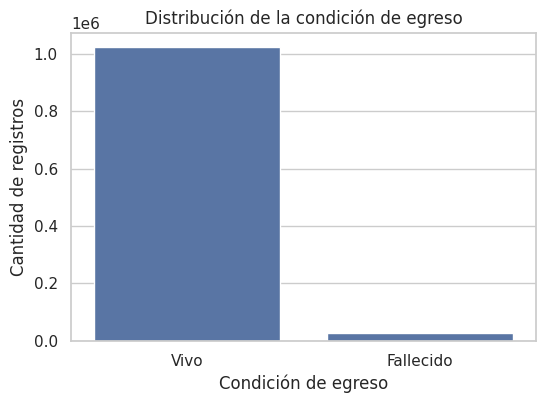

In [ ]:
# ============================================================
# Distribución de la variable objetivo
# ============================================================

dist_objetivo = (
    df.groupBy("CONDICION_EGRESO")
    .count()
    .withColumn("porcentaje", (col("count") / total_registros * 100))
    .orderBy("CONDICION_EGRESO")
)

dist_objetivo.show()

dist_objetivo_pd = dist_objetivo.toPandas()
dist_objetivo_pd["CONDICION_EGRESO"] = dist_objetivo_pd["CONDICION_EGRESO"].replace({
    1.0: "Vivo",
    2.0: "Fallecido"
})

plt.figure(figsize=(6,4))
sns.barplot(data=dist_objetivo_pd, x="CONDICION_EGRESO", y="count")
plt.title("Distribución de la condición de egreso")
plt.xlabel("Condición de egreso")
plt.ylabel("Cantidad de registros")
plt.show()

In [ ]:
# ============================================================
# Distribuciones principales de variables categóricas
# ============================================================

variables_categoricas_revision = [
    "SEXO",
    "GRUPO_EDAD",
    "GLOSA_PREVISION",
    "GLOSA_REGION_RESIDENCIA",
    "GLOSA_PAIS_ORIGEN"
]

for variable in variables_categoricas_revision:
    print("\nVariable:", variable)
    (
        df.groupBy(variable)
        .count()
        .orderBy(desc("count"))
        .show(10, truncate=False)
    )


Variable: SEXO
+----+------+
|SEXO|count |
+----+------+
|2   |595123|
|1   |453452|
+----+------+


Variable: GRUPO_EDAD
+------------+-----+
|GRUPO_EDAD  |count|
+------------+-----+
|30 A 34 AÑOS|85729|
|35 A 39 AÑOS|75284|
|65 A 69 AÑOS|74336|
|60 A 64 AÑOS|73853|
|25 A 29 AÑOS|71066|
|70 A 74 AÑOS|67665|
|55 A 59 AÑOS|65368|
|40 A 44 AÑOS|60481|
|75 A 79 AÑOS|58839|
|50 A 54 AÑOS|57159|
+------------+-----+
only showing top 10 rows


Variable: GLOSA_PREVISION
+---------------+------+
|GLOSA_PREVISION|count |
+---------------+------+
|FONASA         |855261|
|ISAPRE         |132470|
|DESCONOCIDO    |16169 |
|DIPRECA        |12949 |
|CAPREDENA      |12452 |
|NINGUNA        |12307 |
|SISA           |6967  |
+---------------+------+


Variable: GLOSA_REGION_RESIDENCIA
+---------------------------+------+
|GLOSA_REGION_RESIDENCIA    |count |
+---------------------------+------+
|Metropolitana de Santiago  |183848|
|De Valparaíso              |166279|
|Del Bíobío                 |16626

+--------------+------+
|CAPITULO_CIE10|count |
+--------------+------+
|K             |150585|
|O             |131411|
|J             |102368|
|I             |97850 |
|N             |95404 |
|S             |74785 |
|C             |61700 |
|M             |55407 |
|E             |44077 |
|D             |35594 |
|T             |29700 |
|F             |28344 |
|Z             |25545 |
|G             |21527 |
|P             |19117 |
|A             |17124 |
|R             |15497 |
|L             |15404 |
|H             |11025 |
|Q             |10673 |
|B             |3586  |
|U             |1852  |
+--------------+------+



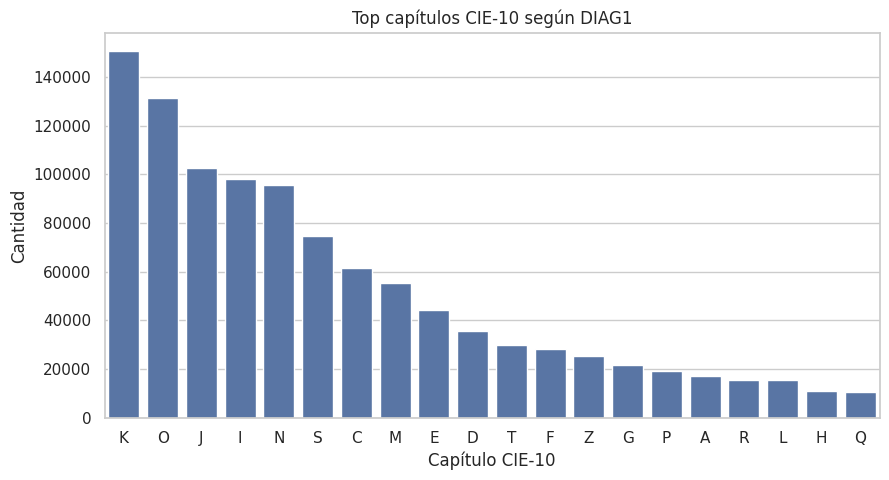

In [ ]:
# ============================================================
# Diagnósticos principales: primera letra del código CIE-10
# ============================================================

df_cie10 = df.withColumn("CAPITULO_CIE10", substring(trim(col("DIAG1")), 1, 1))

dist_cie10 = (
    df_cie10.groupBy("CAPITULO_CIE10")
    .count()
    .orderBy(desc("count"))
)

dist_cie10.show(25, truncate=False)

dist_cie10_pd = dist_cie10.toPandas().head(20)

plt.figure(figsize=(10,5))
sns.barplot(data=dist_cie10_pd, x="CAPITULO_CIE10", y="count")
plt.title("Top capítulos CIE-10 según DIAG1")
plt.xlabel("Capítulo CIE-10")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
# ============================================================
# Estadía hospitalaria
# ============================================================

df.select("DIAS_ESTADA").describe().show()

estadias_extremas = (
    df.orderBy(desc("DIAS_ESTADA"))
    .select("GRUPO_EDAD", "GLOSA_REGION_RESIDENCIA", "DIAG1", "DIAS_ESTADA", "CONDICION_EGRESO")
    .show(10, truncate=False)
)

+-------+-----------------+
|summary|      DIAS_ESTADA|
+-------+-----------------+
|  count|          1048575|
|   mean|6.216955391841308|
| stddev|33.31127193444281|
|    min|              1.0|
|    max|          15162.0|
+-------+-----------------+

+------------------------+-------------------------+-----+-----------+----------------+
|GRUPO_EDAD              |GLOSA_REGION_RESIDENCIA  |DIAG1|DIAS_ESTADA|CONDICION_EGRESO|
+------------------------+-------------------------+-----+-----------+----------------+
|20 A 24 AÑOS            |De Valparaíso            |F720 |15162.0    |1.0             |
|30 A 34 AÑOS            |De Valparaíso            |F729 |9950.0     |1.0             |
|55 A 59 AÑOS            |Metropolitana de Santiago|F079 |7750.0     |1.0             |
|55 A 59 AÑOS            |De Valparaíso            |F202 |6476.0     |1.0             |
|2 MESES A MENOS DE 1 AÑO|Metropolitana de Santiago|J449 |5890.0     |1.0             |
|70 A 74 AÑOS            |Metropolitana de 

# FASE 3 — Preparación de los datos

En esta fase se corrigen tipos, se crean variables derivadas, se define la variable `label`, se prepara el conjunto para una futura Fase 4 y se construye un pipeline de transformación.

No se entrena ningún modelo predictivo en este notebook.

In [ ]:
# ============================================================
# Limpieza base
# ============================================================

df_clean = df

# Limpiar espacios en variables de texto
for c, tipo in df_clean.dtypes:
    if tipo == "string":
        df_clean = df_clean.withColumn(c, trim(col(c)))
        df_clean = df_clean.withColumn(c, when(col(c) == "", None).otherwise(col(c)))

# Mantener solo registros válidos para el problema
df_clean = df_clean.filter(col("CONDICION_EGRESO").isin([1.0, 2.0]))
df_clean = df_clean.filter(col("ANO_EGRESO") == 2024)
df_clean = df_clean.filter(col("DIAS_ESTADA").isNotNull())
df_clean = df_clean.filter(col("DIAS_ESTADA") >= 1)

print("Registros después de filtros básicos:", df_clean.count())

Registros después de filtros básicos: 1048575


In [ ]:
# ============================================================
# Creación de variable objetivo y variables derivadas
# ============================================================

df_modelo = (
    df_clean
    # label: 0 = vivo, 1 = fallecido
    .withColumn(
        "label",
        when(col("CONDICION_EGRESO") == 2.0, lit(1.0)).otherwise(lit(0.0))
    )
    # Reducir cardinalidad de DIAG1 usando solo el capítulo CIE-10
    .withColumn("CAPITULO_CIE10", substring(trim(col("DIAG1")), 1, 1))
    # Indicador de existencia de diagnóstico secundario / causa externa
    .withColumn(
        "TIENE_DIAG2",
        when(col("DIAG2").isNotNull() & (trim(col("DIAG2")) != ""), lit(1.0)).otherwise(lit(0.0))
    )
    # Indicador de país de origen Chile
    .withColumn(
        "ES_CHILE",
        when(col("GLOSA_PAIS_ORIGEN") == "Chile", lit(1.0)).otherwise(lit(0.0))
    )
    # Transformación logarítmica para analizar estadía sin que los valores extremos dominen
    .withColumn("DIAS_ESTADA_LOG", log1p(col("DIAS_ESTADA")))
)

df_modelo.select(
    "CONDICION_EGRESO", "label", "DIAG1", "CAPITULO_CIE10",
    "DIAG2", "TIENE_DIAG2", "GLOSA_PAIS_ORIGEN", "ES_CHILE",
    "DIAS_ESTADA", "DIAS_ESTADA_LOG"
).show(10, truncate=False)

+----------------+-----+-----+--------------+-----+-----------+-----------------+--------+-----------+------------------+
|CONDICION_EGRESO|label|DIAG1|CAPITULO_CIE10|DIAG2|TIENE_DIAG2|GLOSA_PAIS_ORIGEN|ES_CHILE|DIAS_ESTADA|DIAS_ESTADA_LOG   |
+----------------+-----+-----+--------------+-----+-----------+-----------------+--------+-----------+------------------+
|1.0             |0.0  |N908 |N             |NULL |0.0        |Argentina        |0.0     |2.0        |1.0986122886681096|
|1.0             |0.0  |O680 |O             |NULL |0.0        |Argentina        |0.0     |4.0        |1.6094379124341003|
|1.0             |0.0  |O757 |O             |NULL |0.0        |Argentina        |0.0     |2.0        |1.0986122886681096|
|1.0             |0.0  |N800 |N             |NULL |0.0        |Argentina        |0.0     |2.0        |1.0986122886681096|
|1.0             |0.0  |O601 |O             |NULL |0.0        |Argentina        |0.0     |3.0        |1.3862943611198906|
|1.0             |0.0  |

In [ ]:
# ============================================================
# Decisión metodológica sobre DIAS_ESTADA
# ============================================================

# Si el objetivo es predecir la condición de egreso con información disponible al inicio,
# DIAS_ESTADA no debería usarse como predictor porque se conoce al final del episodio.
# Por eso se deja en False por defecto.
#
# Si el profesor les indica que el análisis es completamente retrospectivo/ex-post,
# pueden cambiarlo a True.

USAR_DIAS_ESTADA_COMO_PREDICTOR = False

if USAR_DIAS_ESTADA_COMO_PREDICTOR:
    print("DIAS_ESTADA_LOG será usada como predictor.")
else:
    print("DIAS_ESTADA_LOG NO será usada como predictor; solo queda para análisis descriptivo.")

DIAS_ESTADA_LOG NO será usada como predictor; solo queda para análisis descriptivo.


In [ ]:
# ============================================================
# Selección de variables predictoras
# ============================================================

# Variables categóricas de baja/media cardinalidad o resumidas.
# No se usa DIAG1 completo porque tiene alta cardinalidad; se usa CAPITULO_CIE10.
# No se usa DIAG2 completo; se usa TIENE_DIAG2.

categorical_cols = [
    "PERTENENCIA_ESTABLECIMIENTO_SALUD",
    "SEXO",
    "GRUPO_EDAD",
    "GLOSA_PAIS_ORIGEN",
    "GLOSA_REGION_RESIDENCIA",
    "GLOSA_PREVISION",
    "CAPITULO_CIE10"
]

numeric_cols = [
    "TIENE_DIAG2",
    "ES_CHILE"
]

if USAR_DIAS_ESTADA_COMO_PREDICTOR:
    numeric_cols.append("DIAS_ESTADA_LOG")

print("Variables categóricas:")
print(categorical_cols)

print("\nVariables numéricas:")
print(numeric_cols)

Variables categóricas:
['PERTENENCIA_ESTABLECIMIENTO_SALUD', 'SEXO', 'GRUPO_EDAD', 'GLOSA_PAIS_ORIGEN', 'GLOSA_REGION_RESIDENCIA', 'GLOSA_PREVISION', 'CAPITULO_CIE10']

Variables numéricas:
['TIENE_DIAG2', 'ES_CHILE']


In [ ]:
# ============================================================
# Separación train/test ANTES de ajustar transformaciones
# ============================================================

# Esto evita fuga de información: los indexadores, imputadores y escaladores
# se ajustan solo con los datos de entrenamiento.

train_base, test_base = df_modelo.randomSplit([0.8, 0.2], seed=2026)

print("Train:", train_base.count())
print("Test:", test_base.count())

print("\nDistribución label en train:")
train_base.groupBy("label").count().orderBy("label").show()

print("Distribución label en test:")
test_base.groupBy("label").count().orderBy("label").show()

Train: 839162
Test: 209413

Distribución label en train:
+-----+------+
|label| count|
+-----+------+
|  0.0|818334|
|  1.0| 20828|
+-----+------+

Distribución label en test:
+-----+------+
|label| count|
+-----+------+
|  0.0|204412|
|  1.0|  5001|
+-----+------+



In [ ]:
# ============================================================
# Pesos de clase calculados solo con train
# ============================================================

conteos_train = {row["label"]: row["count"] for row in train_base.groupBy("label").count().collect()}
total_train = sum(conteos_train.values())
n_clases = len(conteos_train)

peso_vivo = total_train / (n_clases * conteos_train.get(0.0, 1))
peso_fallecido = total_train / (n_clases * conteos_train.get(1.0, 1))

print("Peso clase vivo label=0:", peso_vivo)
print("Peso clase fallecido label=1:", peso_fallecido)

def agregar_peso_clase(df_entrada):
    return df_entrada.withColumn(
        "classWeightCol",
        when(col("label") == 1.0, lit(float(peso_fallecido))).otherwise(lit(float(peso_vivo)))
    )

train_base = agregar_peso_clase(train_base)
test_base = agregar_peso_clase(test_base)

Peso clase vivo label=0: 0.5127258552131526
Peso clase fallecido label=1: 20.145045131553676


In [ ]:
# ============================================================
# Pipeline de preparación con Spark ML
# ============================================================

# 1. StringIndexer: transforma categorías a índices.
# 2. OneHotEncoder: convierte índices categóricos en vectores binarios.
# 3. Imputer: rellena nulos en variables numéricas.
# 4. VectorAssembler: une variables en un vector.
# 5. StandardScaler: escala el vector final.

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_ohe",
        dropLast=True
    )
    for c in categorical_cols
]

numeric_imputed_cols = [f"{c}_imp" for c in numeric_cols]

imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=numeric_imputed_cols,
    strategy="median"
)

assembler_inputs = [f"{c}_ohe" for c in categorical_cols] + numeric_imputed_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

pipeline_preparacion = Pipeline(
    stages=indexers + encoders + [imputer, assembler, scaler]
)

pipeline_model = pipeline_preparacion.fit(train_base)

train_data = pipeline_model.transform(train_base)
test_data = pipeline_model.transform(test_base)

print("Pipeline de preparación ajustado correctamente.")
print("Columnas finales principales:")
train_data.select("features", "label", "classWeightCol").show(5, truncate=False)

Pipeline de preparación ajustado correctamente.
Columnas finales principales:
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+------------------+
|features                                                                                                                                                            |label|classWeightCol    |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+------------------+
|(102,[0,2,19,32,60,71,83,100],[0.0,2.0186442200547896,5.840323469675129,51.87117658670616,2.7362545137641594,2.5786479166680443,3.891305332279205,3.33980098650348])|0.0  |0.5127258552131526|
|(102,[0,2,19,32,64,71,94],[0.0,2.0186442200547896,5.840323469675129,51.87117658670616,3.864425505733375,2.5786479166680443,8.271490096001266])           

In [ ]:
# ============================================================
# Validación final de la preparación
# ============================================================

vector_ejemplo = train_data.select("features").first()[0]

print("Dimensión del vector features:", vector_ejemplo.size)
print("Cantidad train preparado:", train_data.count())
print("Cantidad test preparado:", test_data.count())

print("\nDistribución final train:")
train_data.groupBy("label").count().orderBy("label").show()

print("Distribución final test:")
test_data.groupBy("label").count().orderBy("label").show()

Dimensión del vector features: 102
Cantidad train preparado: 839162
Cantidad test preparado: 209413

Distribución final train:
+-----+------+
|label| count|
+-----+------+
|  0.0|818334|
|  1.0| 20828|
+-----+------+

Distribución final test:
+-----+------+
|label| count|
+-----+------+
|  0.0|204412|
|  1.0|  5001|
+-----+------+



In [ ]:
# Guardado de resultados de Fase 3

os.makedirs("output", exist_ok=True)

ruta_train = "output/egresos_2024_train_fase3"
ruta_test = "output/egresos_2024_test_fase3"
ruta_pipeline = "output/pipeline_preparacion_egresos_2024"

columnas_salida = [
    "features", "features_raw", "label", "classWeightCol",
    "CONDICION_EGRESO", "GRUPO_EDAD", "GLOSA_REGION_RESIDENCIA",
    "GLOSA_PREVISION", "CAPITULO_CIE10"
]

train_data.select(columnas_salida).write.mode("overwrite").parquet(ruta_train)
test_data.select(columnas_salida).write.mode("overwrite").parquet(ruta_test)
pipeline_model.write().overwrite().save(ruta_pipeline)

print("Archivos guardados en ./output/")


Archivos guardados:
Train: /content/egresos_2024_train_fase3
Test: /content/egresos_2024_test_fase3
Pipeline: /content/pipeline_preparacion_egresos_2024


## Cierre de Fase 3

Con este notebook queda completado lo siguiente:

- **Fase 1:** definición del problema, objetivo y variable objetivo.
- **Fase 2:** carga, reconstrucción, exploración, revisión de nulos, duplicados, distribución de clases y análisis descriptivo.
- **Fase 3:** limpieza, creación de `label`, variables derivadas, separación train/test sin fuga de información, cálculo de pesos de clase y pipeline de preparación.

La futura **Fase 4** podría usar `train_data`, `test_data` y `pipeline_model`, pero no se desarrolla en este notebook porque el enunciado solicitado solo pide Fases 1, 2 y 3.

# FASE 4 — Modelado con enfoque híbrido para desbalance de clases

En esta fase se entrenan dos enfoques de clasificación binaria para predecir la condición de egreso:

- **Enfoque A:** Regresión Logística con regularización **L2**, **L1** y **Elastic Net**, incluyendo análisis de coeficientes.
- **Enfoque B:** **Random Forest**, incluyendo gráfico de importancia de variables.

Dado que el problema presenta **desbalance de clases** —muchos pacientes egresan vivos y pocos fallecen—, se utiliza un **sistema híbrido de modelado**:

1. **Modelos supervisados de clasificación**: Regresión Logística regularizada y Random Forest.
2. **Tratamiento del desbalance mediante pesos de clase**: la clase minoritaria (`label = 1`, fallecido) recibe mayor peso usando `classWeightCol`.
3. **Pipelines completos de Spark ML**: cada modelo queda encapsulado junto con la preparación de datos de Fase 3.

Este enfoque es más coherente para Spark que aplicar SMOTE directamente, porque Spark ML permite entrenar modelos ponderados con `weightCol`, manteniendo escalabilidad y evitando duplicar artificialmente registros.

> Nota: esta fase usa `train_base` y `test_base`, no `train_data` y `test_data`, para que cada pipeline incluya preparación + modelo desde los datos base ya limpios.

## 4.0b Alternativa GPU - XGBoost con CUDA

Si dispones de GPU NVIDIA, esta celda usa **XGBoost acelerado por GPU** como modelo adicional.
La celda detecta automaticamente si hay GPU disponible; si no, usa CPU automaticamente.

**Requisito:** drivers NVIDIA instalados. XGBoost incluye soporte CUDA sin instalar CUDA manualmente.

In [ ]:
# XGBoost con GPU (complemento al Random Forest de PySpark)

import subprocess
import xgboost as xgb
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from pyspark.ml.functions import vector_to_array

# Detectar GPU
try:
    gpu_check = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                               capture_output=True, text=True)
    GPU_DISPONIBLE = gpu_check.returncode == 0 and gpu_check.stdout.strip() != ""
    if GPU_DISPONIBLE:
        print("GPU detectada:", gpu_check.stdout.strip())
except Exception:
    GPU_DISPONIBLE = False

DEVICE = "cuda" if GPU_DISPONIBLE else "cpu"
print(f"XGBoost usara: {DEVICE}")

# Convertir datos Spark a numpy para XGBoost
def spark_to_numpy(df_spark):
    pdf = df_spark.select(vector_to_array("features").alias("features"), "label").toPandas()
    X = np.array(pdf["features"].tolist())
    y = pdf["label"].values
    return X, y

print("Convirtiendo datos Spark a numpy...")
X_train_np, y_train_np = spark_to_numpy(train_data)
X_test_np,  y_test_np  = spark_to_numpy(test_data)

scale_pw = float((y_train_np == 0).sum()) / max(float((y_train_np == 1).sum()), 1)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pw,
    eval_metric="auc",
    device=DEVICE,
    random_state=2026,
    verbosity=1,
)

print("Entrenando XGBoost...")
xgb_clf.fit(X_train_np, y_train_np, eval_set=[(X_test_np, y_test_np)], verbose=50)

y_proba = xgb_clf.predict_proba(X_test_np)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test_np)

print(f"\nXGBoost ({DEVICE.upper()}) - Resultados:")
print(f"  AUC-ROC : {roc_auc_score(y_test_np, y_proba):.4f}")
print(f"  F1-Score: {f1_score(y_test_np, y_pred_xgb, average=chr(34)+chr(119)+chr(101)+chr(105)+chr(103)+chr(104)+chr(116)+chr(101)+chr(100)+chr(34)):.4f}")
print()
print(classification_report(y_test_np, y_pred_xgb, target_names=["Vivo", "Fallecido"]))


In [ ]:
# ============================================================
# Imports específicos de Fase 4
# ============================================================

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

import math

## 4.0 Estrategia híbrida frente al desbalance

El dataset de egresos hospitalarios está desbalanceado: la mayoría de los registros corresponde a pacientes vivos y una minoría a pacientes fallecidos. Si no se corrige esto, los modelos pueden aprender a predecir casi siempre la clase mayoritaria.

Por eso se utiliza una estrategia híbrida:

- Se mantienen dos familias de modelos supervisados: uno lineal e interpretable y otro basado en árboles.
- Se incorpora `classWeightCol` para penalizar más los errores sobre la clase minoritaria.
- Los pesos se calculan **solo con el conjunto de entrenamiento**, evitando fuga de información desde el test.

La fórmula usada es:

$$
\text{peso clase} = \frac{\text{total de registros train}}{\text{número de clases} \times \text{cantidad de registros de la clase}}
$$

Así, la clase fallecido recibe un peso mayor porque aparece con menor frecuencia.

In [ ]:
# ============================================================
# Verificación del desbalance y pesos de clase para Fase 4
# ============================================================

# Esta celda confirma que classWeightCol existe y que fue calculada desde train_base.
# Si la columna no existe, se recalcula de manera segura usando solo los datos de entrenamiento.

from pyspark.sql.functions import col, lit, when

print("Distribución de clases en train_base:")
train_base.groupBy("label").count().orderBy("label").show()

print("Distribución de clases en test_base:")
test_base.groupBy("label").count().orderBy("label").show()

if "classWeightCol" not in train_base.columns:
    conteos_train_f4 = {row["label"]: row["count"] for row in train_base.groupBy("label").count().collect()}
    total_train_f4 = sum(conteos_train_f4.values())
    n_clases_f4 = len(conteos_train_f4)

    peso_vivo_f4 = total_train_f4 / (n_clases_f4 * conteos_train_f4.get(0.0, 1))
    peso_fallecido_f4 = total_train_f4 / (n_clases_f4 * conteos_train_f4.get(1.0, 1))

    train_base = train_base.withColumn(
        "classWeightCol",
        when(col("label") == 1.0, lit(float(peso_fallecido_f4))).otherwise(lit(float(peso_vivo_f4)))
    )

    test_base = test_base.withColumn(
        "classWeightCol",
        when(col("label") == 1.0, lit(float(peso_fallecido_f4))).otherwise(lit(float(peso_vivo_f4)))
    )
else:
    print("La columna classWeightCol ya existe desde Fase 3.")

print("Pesos aplicados por clase en train_base:")
train_base.groupBy("label", "classWeightCol").count().orderBy("label").show()

print("Pesos aplicados por clase en test_base:")
test_base.groupBy("label", "classWeightCol").count().orderBy("label").show()


Distribución de clases en train_base:
+-----+------+
|label| count|
+-----+------+
|  0.0|818334|
|  1.0| 20828|
+-----+------+

Distribución de clases en test_base:
+-----+------+
|label| count|
+-----+------+
|  0.0|204412|
|  1.0|  5001|
+-----+------+

La columna classWeightCol ya existe desde Fase 3.
Pesos aplicados por clase en train_base:
+-----+------------------+------+
|label|    classWeightCol| count|
+-----+------------------+------+
|  0.0|0.5127258552131526|818334|
|  1.0|20.145045131553676| 20828|
+-----+------------------+------+

Pesos aplicados por clase en test_base:
+-----+------------------+------+
|label|    classWeightCol| count|
+-----+------------------+------+
|  0.0|0.5127258552131526|204412|
|  1.0|20.145045131553676|  5001|
+-----+------------------+------+



In [ ]:
# ============================================================
# Evaluadores auxiliares para revisar desempeño inicial
# ============================================================

# Aunque la evaluación formal puede quedar para Fase 5, aquí se calculan métricas básicas
# para verificar que los modelos entrenan y generan predicciones coherentes.

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

def evaluar_modelo(predicciones, nombre_modelo):
    """Calcula métricas básicas para un modelo Spark de clasificación binaria."""
    auc = evaluator_auc.evaluate(predicciones)
    f1 = evaluator_f1.evaluate(predicciones)
    accuracy = evaluator_accuracy.evaluate(predicciones)

    print(f"Modelo: {nombre_modelo}")
    print(f"AUC-ROC : {auc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nMatriz de conteo label vs prediction:")
    predicciones.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

    return {
        "modelo": nombre_modelo,
        "auc_roc": float(auc),
        "f1": float(f1),
        "accuracy": float(accuracy)
    }

## 4.1 Enfoque A — Regresión Logística regularizada

Se entrenan tres versiones del mismo algoritmo:

1. **L2 / Ridge:** penaliza coeficientes grandes, pero normalmente no los lleva a cero.
2. **L1 / Lasso:** puede dejar coeficientes exactamente en cero, ayudando a selección de variables.
3. **Elastic Net:** combina L1 y L2.

En Spark esto se controla con:

- `regParam`: intensidad de la regularización.
- `elasticNetParam = 0.0`: L2.
- `elasticNetParam = 1.0`: L1.
- `elasticNetParam = 0.5`: Elastic Net.

In [ ]:
# ============================================================
# Enfoque A: pipelines con Regresión Logística L2, L1 y Elastic Net
# ============================================================

# IMPORTANTE:
# Cada pipeline contiene:
# preparación de Fase 3 + algoritmo de clasificación.
# Además, cada modelo usa weightCol="classWeightCol" para manejar el desbalance.
# Por eso se ajusta sobre train_base, no sobre train_data.

stages_preparacion = pipeline_preparacion.getStages()

lr_l2 = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol",
    maxIter=50,
    regParam=0.10,
    elasticNetParam=0.0,  # L2 / Ridge
    standardization=False,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction"
)

lr_l1 = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol",
    maxIter=50,
    regParam=0.10,
    elasticNetParam=1.0,  # L1 / Lasso
    standardization=False,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction"
)

lr_elastic = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol",
    maxIter=50,
    regParam=0.10,
    elasticNetParam=0.5,  # Elastic Net
    standardization=False,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction"
)

pipeline_lr_l2 = Pipeline(stages=stages_preparacion + [lr_l2])
pipeline_lr_l1 = Pipeline(stages=stages_preparacion + [lr_l1])
pipeline_lr_elastic = Pipeline(stages=stages_preparacion + [lr_elastic])

print("Pipelines del Enfoque A creados correctamente.")
print("Cada pipeline incluye preparación + modelo de Regresión Logística ponderado por classWeightCol.")

Pipelines del Enfoque A creados correctamente.
Cada pipeline incluye preparación + modelo de Regresión Logística ponderado por classWeightCol.


In [ ]:
# ============================================================
# Entrenamiento de Regresión Logística regularizada
# ============================================================

modelo_lr_l2 = pipeline_lr_l2.fit(train_base)
modelo_lr_l1 = pipeline_lr_l1.fit(train_base)
modelo_lr_elastic = pipeline_lr_elastic.fit(train_base)

pred_lr_l2 = modelo_lr_l2.transform(test_base)
pred_lr_l1 = modelo_lr_l1.transform(test_base)
pred_lr_elastic = modelo_lr_elastic.transform(test_base)

print("Modelos de Regresión Logística entrenados correctamente.")

Modelos de Regresión Logística entrenados correctamente.


In [ ]:
# ============================================================
# Revisión básica de resultados del Enfoque A
# ============================================================

resultados_fase4 = []

resultados_fase4.append(evaluar_modelo(pred_lr_l2, "Regresión Logística L2"))
resultados_fase4.append(evaluar_modelo(pred_lr_l1, "Regresión Logística L1"))
resultados_fase4.append(evaluar_modelo(pred_lr_elastic, "Regresión Logística Elastic Net"))

pd.DataFrame(resultados_fase4)

Modelo: Regresión Logística L2
AUC-ROC : 0.8641
F1-score: 0.8455
Accuracy: 0.7633

Matriz de conteo label vs prediction:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|155803|
|  0.0|       1.0| 48609|
|  1.0|       0.0|   956|
|  1.0|       1.0|  4045|
+-----+----------+------+

Modelo: Regresión Logística L1
AUC-ROC : 0.7068
F1-score: 0.8838
Accuracy: 0.8242

Matriz de conteo label vs prediction:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|169770|
|  0.0|       1.0| 34642|
|  1.0|       0.0|  2177|
|  1.0|       1.0|  2824|
+-----+----------+------+

Modelo: Regresión Logística Elastic Net
AUC-ROC : 0.8251
F1-score: 0.8641
Accuracy: 0.7922

Matriz de conteo label vs prediction:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|162677|
|  0.0|       1.0| 41735|
|  1.0|       0.0|  1775|
|  1.0|       1.0|  3226|
+-----+----------+------+



,modelo,auc_roc,f1,accuracy
0,Regresión Logística L2,0.864069,0.845513,0.763315
1,Regresión Logística L1,0.706759,0.883802,0.824180
2,Regresión Logística Elastic Net,0.825136,0.864063,0.792229


In [ ]:
# ============================================================
# Funciones para obtener nombres de variables después de OneHotEncoder
# ============================================================

def obtener_nombres_features(modelo_pipeline, categorical_cols, numeric_cols):
    """
    Reconstruye nombres aproximados de las variables finales del vector features.
    Considera StringIndexer + OneHotEncoder + variables numéricas imputadas.
    """
    stages = modelo_pipeline.stages

    n_cat = len(categorical_cols)
    indexer_models = stages[:n_cat]
    encoder_models = stages[n_cat:2*n_cat]

    nombres = []

    for nombre_col, indexer_model, encoder_model in zip(categorical_cols, indexer_models, encoder_models):
        labels = list(indexer_model.labels)
        category_size = encoder_model.categorySizes[0]

        # Como dropLast=True, se generan category_size - 1 columnas.
        for i in range(category_size - 1):
            if i < len(labels):
                categoria = labels[i]
            else:
                categoria = "categoria_invalida_o_nula"
            nombres.append(f"{nombre_col}={categoria}")

    # Las columnas numéricas entran después de las categóricas codificadas.
    nombres.extend(numeric_cols)

    return nombres


def analizar_coeficientes_lr(modelo_pipeline, nombre_modelo, top_n=15):
    """Entrega una tabla ordenada con los coeficientes de una Regresión Logística."""
    lr_model = modelo_pipeline.stages[-1]
    coeficientes = lr_model.coefficients.toArray()
    intercepto = lr_model.intercept

    nombres_features = obtener_nombres_features(modelo_pipeline, categorical_cols, numeric_cols)

    if len(nombres_features) != len(coeficientes):
        print("Advertencia: cantidad de nombres no coincide con cantidad de coeficientes.")
        print("Nombres:", len(nombres_features), "Coeficientes:", len(coeficientes))
        nombres_features = [f"feature_{i}" for i in range(len(coeficientes))]

    tabla = pd.DataFrame({
        "feature": nombres_features,
        "coeficiente": coeficientes
    })

    tabla["coef_abs"] = tabla["coeficiente"].abs()
    tabla["odds_ratio_aprox"] = np.exp(np.clip(tabla["coeficiente"], -20, 20))
    tabla = tabla.sort_values("coef_abs", ascending=False).reset_index(drop=True)

    n_coef_cero = int((np.abs(coeficientes) < 1e-8).sum())
    n_coef_total = len(coeficientes)

    print("=" * 70)
    print(nombre_modelo)
    print("Intercepto:", round(float(intercepto), 6))
    print("Coeficientes totales:", n_coef_total)
    print("Coeficientes exactamente o casi cero:", n_coef_cero)
    print("Porcentaje de coeficientes en cero:", round(100 * n_coef_cero / n_coef_total, 2), "%")
    print("=" * 70)

    print("\nVariables con mayor efecto positivo sobre label=1, es decir, egreso fallecido:")
    display(tabla.sort_values("coeficiente", ascending=False).head(top_n))

    print("\nVariables con mayor efecto negativo sobre label=1, es decir, asociadas a egreso vivo:")
    display(tabla.sort_values("coeficiente", ascending=True).head(top_n))

    return tabla

In [ ]:
# ============================================================
# Análisis de coeficientes del Enfoque A
# ============================================================

coef_lr_l2 = analizar_coeficientes_lr(modelo_lr_l2, "Regresión Logística L2", top_n=15)
coef_lr_l1 = analizar_coeficientes_lr(modelo_lr_l1, "Regresión Logística L1", top_n=15)
coef_lr_elastic = analizar_coeficientes_lr(modelo_lr_elastic, "Regresión Logística Elastic Net", top_n=15)

Regresión Logística L2
Intercepto: -0.941549
Coeficientes totales: 102
Coeficientes exactamente o casi cero: 1
Porcentaje de coeficientes en cero: 0.98 %

Variables con mayor efecto positivo sobre label=1, es decir, egreso fallecido:


,feature,coeficiente,coef_abs,odds_ratio_aprox
0,GRUPO_EDAD=85 A MAS,0.309943,0.309943,1.363348
1,CAPITULO_CIE10=J,0.281765,0.281765,1.325468
2,GRUPO_EDAD=80 A 84 AÑOS,0.233538,0.233538,1.263061
4,GRUPO_EDAD=75 A 79 AÑOS,0.203491,0.203491,1.225675
5,CAPITULO_CIE10=A,0.187073,0.187073,1.205715
8,CAPITULO_CIE10=I,0.172215,0.172215,1.187934
9,CAPITULO_CIE10=C,0.171859,0.171859,1.187510
10,GRUPO_EDAD=70 A 74 AÑOS,0.170859,0.170859,1.186324
14,GRUPO_EDAD=65 A 69 AÑOS,0.134874,0.134874,1.144393
20,GLOSA_PREVISION=FONASA,0.104128,0.104128,1.109743



Variables con mayor efecto negativo sobre label=1, es decir, asociadas a egreso vivo:


,feature,coeficiente,coef_abs,odds_ratio_aprox
3,CAPITULO_CIE10=O,-0.231545,0.231545,0.793307
6,GRUPO_EDAD=1 A 4 AÑOS,-0.182808,0.182808,0.832928
7,GRUPO_EDAD=5 A 9 AÑOS,-0.174744,0.174744,0.839672
11,CAPITULO_CIE10=M,-0.170711,0.170711,0.843065
12,GRUPO_EDAD=30 A 34 AÑOS,-0.154424,0.154424,0.856908
13,GRUPO_EDAD=25 A 29 AÑOS,-0.137604,0.137604,0.871444
15,GRUPO_EDAD=10 A 14 AÑOS,-0.130930,0.130930,0.877279
16,GRUPO_EDAD=20 A 24 AÑOS,-0.124882,0.124882,0.882601
17,GLOSA_PREVISION=ISAPRE,-0.124335,0.124335,0.883084
18,GRUPO_EDAD=15 A 19 AÑOS,-0.114402,0.114402,0.891899


Regresión Logística L1
Intercepto: -0.203521
Coeficientes totales: 102
Coeficientes exactamente o casi cero: 98
Porcentaje de coeficientes en cero: 96.08 %

Variables con mayor efecto positivo sobre label=1, es decir, egreso fallecido:


...

,feature,coeficiente,coef_abs,odds_ratio_aprox
7,GRUPO_EDAD=35 A 39 AÑOS,0.0,0.0,1.0
6,GRUPO_EDAD=65 A 69 AÑOS,0.0,0.0,1.0
5,GRUPO_EDAD=30 A 34 AÑOS,0.0,0.0,1.0
4,SEXO=1,0.0,0.0,1.0
11,GRUPO_EDAD=75 A 79 AÑOS,0.0,0.0,1.0
10,GRUPO_EDAD=40 A 44 AÑOS,0.0,0.0,1.0
9,GRUPO_EDAD=25 A 29 AÑOS,0.0,0.0,1.0
8,GRUPO_EDAD=60 A 64 AÑOS,0.0,0.0,1.0
12,GRUPO_EDAD=70 A 74 AÑOS,0.0,0.0,1.0
13,GRUPO_EDAD=55 A 59 AÑOS,0.0,0.0,1.0


Regresión Logística Elastic Net
Intercepto: -0.534841
Coeficientes totales: 102
Coeficientes exactamente o casi cero: 91
Porcentaje de coeficientes en cero: 89.22 %

Variables con mayor efecto positivo sobre label=1, es decir, egreso fallecido:


,feature,coeficiente,coef_abs,odds_ratio_aprox
0,GRUPO_EDAD=85 A MAS,0.242290,0.242290,1.274164
1,CAPITULO_CIE10=J,0.213889,0.213889,1.238485
2,GRUPO_EDAD=80 A 84 AÑOS,0.158276,0.158276,1.171490
3,CAPITULO_CIE10=I,0.127105,0.127105,1.135537
5,CAPITULO_CIE10=A,0.116562,0.116562,1.123628
6,GRUPO_EDAD=75 A 79 AÑOS,0.116439,0.116439,1.123489
7,CAPITULO_CIE10=C,0.082613,0.082613,1.086122
8,GRUPO_EDAD=70 A 74 AÑOS,0.069194,0.069194,1.071644
9,GRUPO_EDAD=65 A 69 AÑOS,0.016197,0.016197,1.016329
30,GLOSA_PAIS_ORIGEN=Haití,0.000000,0.000000,1.000000



Variables con mayor efecto negativo sobre label=1, es decir, asociadas a egreso vivo:


,feature,coeficiente,coef_abs,odds_ratio_aprox
4,CAPITULO_CIE10=O,-0.119537,0.119537,0.887331
10,GLOSA_PREVISION=ISAPRE,-0.001284,0.001284,0.998717
15,GRUPO_EDAD=50 A 54 AÑOS,0.000000,0.000000,1.000000
13,GRUPO_EDAD=60 A 64 AÑOS,0.000000,0.000000,1.000000
12,GRUPO_EDAD=35 A 39 AÑOS,0.000000,0.000000,1.000000
14,GRUPO_EDAD=45 A 49 AÑOS,0.000000,0.000000,1.000000
11,GRUPO_EDAD=30 A 34 AÑOS,0.000000,0.000000,1.000000
24,GRUPO_EDAD=28 DIAS A 2 MES,0.000000,0.000000,1.000000
23,GRUPO_EDAD=7 A 27 DIAS,0.000000,0.000000,1.000000
22,GRUPO_EDAD=2 MESES A MENOS DE 1 AÑO,0.000000,0.000000,1.000000


## 4.2 Enfoque B — Random Forest

El segundo enfoque usa **Random Forest**, un modelo basado en árboles que permite capturar relaciones no lineales e interacciones entre variables.

Ventajas para este problema:

- Tolera relaciones no lineales.
- Es robusto frente a variables categóricas transformadas con OneHotEncoder.
- Permite obtener **importancia de variables** para interpretar qué predictores aportan más al modelo.

El modelo también queda dentro de un pipeline completo: preparación + Random Forest.

In [ ]:
# ============================================================
# Enfoque B: Pipeline con Random Forest ponderado
# ============================================================

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol",
    numTrees=80,
    maxDepth=8,
    minInstancesPerNode=5,
    featureSubsetStrategy="sqrt",
    seed=2026,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction"
)

pipeline_rf = Pipeline(stages=stages_preparacion + [rf])

print("Pipeline del Enfoque B creado correctamente.")
print("El pipeline incluye preparación + Random Forest ponderado por classWeightCol.")

Pipeline del Enfoque B creado correctamente.
El pipeline incluye preparación + Random Forest ponderado por classWeightCol.


In [ ]:
# ============================================================
# Entrenamiento de Random Forest
# ============================================================

modelo_rf = pipeline_rf.fit(train_base)
pred_rf = modelo_rf.transform(test_base)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


In [ ]:
# ============================================================
# Revisión básica de resultados del Enfoque B
# ============================================================

resultados_fase4.append(evaluar_modelo(pred_rf, "Random Forest"))

tabla_resultados_fase4 = pd.DataFrame(resultados_fase4).sort_values("auc_roc", ascending=False)
tabla_resultados_fase4

Modelo: Random Forest
AUC-ROC : 0.8559
F1-score: 0.8447
Accuracy: 0.7620

Matriz de conteo label vs prediction:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|  0.0|       0.0|155634|
|  0.0|       1.0| 48778|
|  1.0|       0.0|  1054|
|  1.0|       1.0|  3947|
+-----+----------+------+



,modelo,auc_roc,f1,accuracy
0,Regresión Logística L2,0.864069,0.845513,0.763315
3,Random Forest,0.855937,0.844680,0.762040
2,Regresión Logística Elastic Net,0.825136,0.864063,0.792229
1,Regresión Logística L1,0.706759,0.883802,0.824180


In [ ]:
# ============================================================
# Importancia de variables del Random Forest
# ============================================================

rf_model = modelo_rf.stages[-1]
importancias = rf_model.featureImportances.toArray()

nombres_features_rf = obtener_nombres_features(modelo_rf, categorical_cols, numeric_cols)

if len(nombres_features_rf) != len(importancias):
    print("Advertencia: cantidad de nombres no coincide con cantidad de importancias.")
    print("Nombres:", len(nombres_features_rf), "Importancias:", len(importancias))
    nombres_features_rf = [f"feature_{i}" for i in range(len(importancias))]

tabla_importancia_rf = pd.DataFrame({
    "feature": nombres_features_rf,
    "importance": importancias
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 20 variables más importantes según Random Forest:")
display(tabla_importancia_rf.head(20))

Top 20 variables más importantes según Random Forest:


,feature,importance
0,GRUPO_EDAD=85 A MAS,0.139565
1,CAPITULO_CIE10=O,0.136324
2,CAPITULO_CIE10=J,0.131520
3,GRUPO_EDAD=80 A 84 AÑOS,0.062621
4,CAPITULO_CIE10=I,0.051526
5,CAPITULO_CIE10=A,0.047843
6,GRUPO_EDAD=25 A 29 AÑOS,0.040588
7,GRUPO_EDAD=30 A 34 AÑOS,0.040546
8,GLOSA_PREVISION=ISAPRE,0.038152
9,GRUPO_EDAD=75 A 79 AÑOS,0.034652


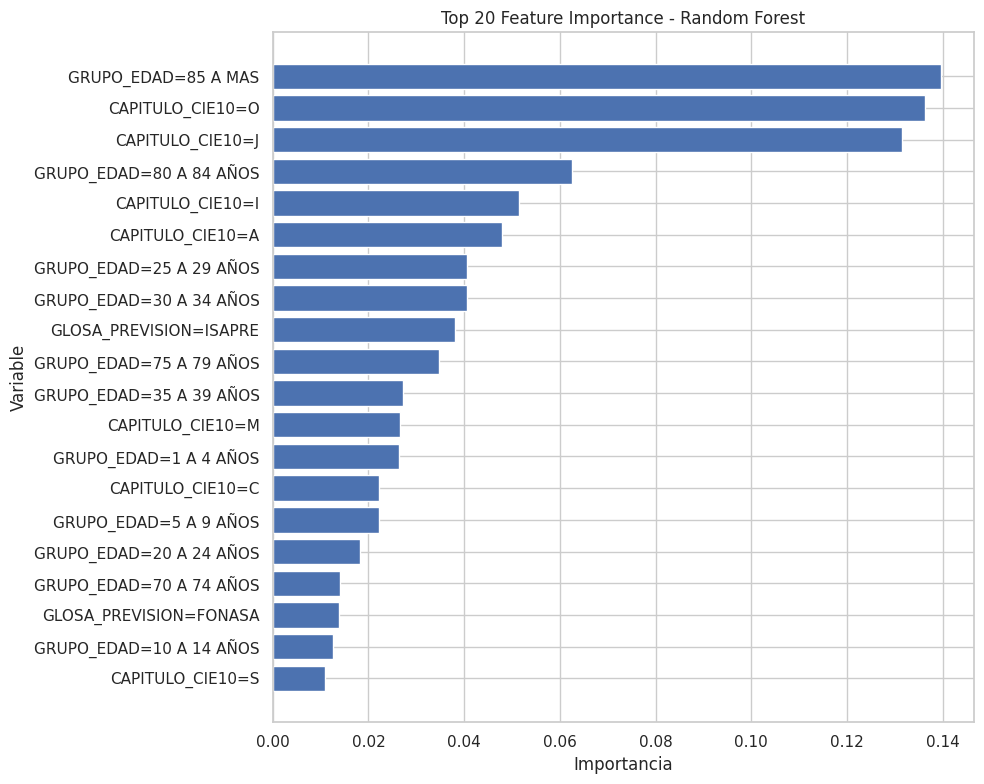

In [ ]:
# ============================================================
# Gráfico de Feature Importance - Random Forest
# ============================================================

top_n = 20
top_importancia = tabla_importancia_rf.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_importancia["feature"], top_importancia["importance"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

## 4.3 Visualizaciones detalladas de los resultados de modelado

Para que la Fase 4 sea más clara visualmente, se agregan gráficos diagnósticos de los modelos entrenados.

> Importante: estas visualizaciones apoyan la interpretación del modelado. La evaluación formal con validación cruzada y búsqueda de hiperparámetros puede quedar para Fase 5.

Se incluyen:

- distribución de clases en train y test;
- gráfico de pesos aplicados por clase;
- matrices de confusión absolutas;
- matrices de confusión normalizadas por clase real;
- curvas ROC comparativas;
- curvas Precision-Recall comparativas;
- comparación visual de métricas relevantes para la clase fallecido.

,label,count,conjunto,clase
0,0.0,818334,Train,Vivo
1,1.0,20828,Train,Fallecido
2,0.0,204412,Test,Vivo
3,1.0,5001,Test,Fallecido


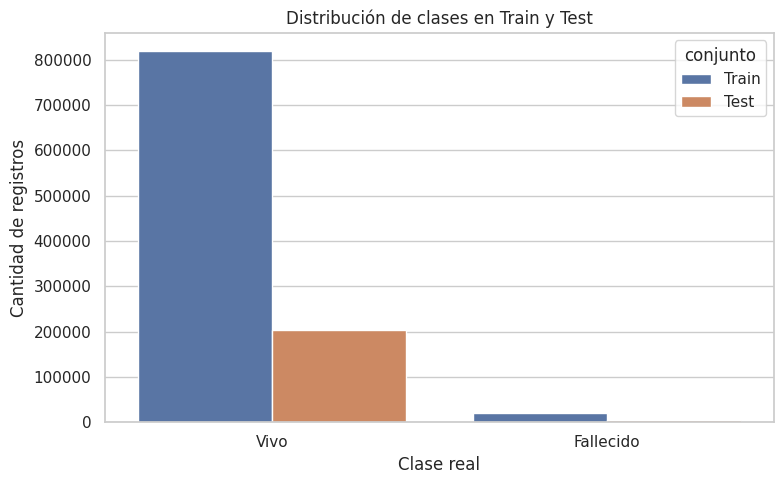

,label,classWeightCol,clase
0,0.0,0.512726,Vivo
1,1.0,20.145045,Fallecido


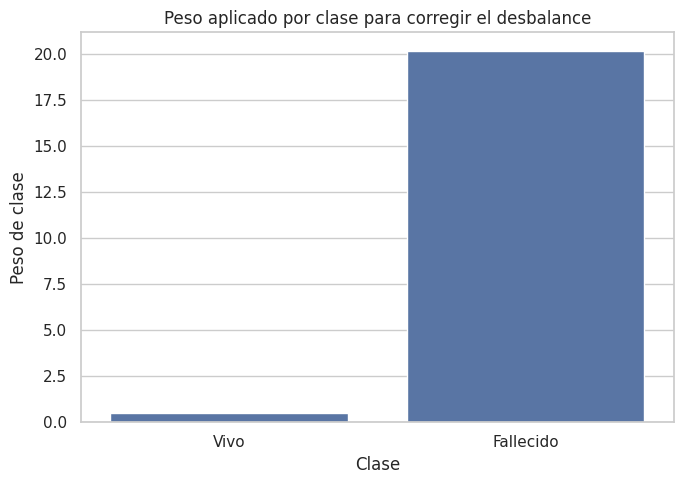

In [ ]:

# ============================================================
# Visualización de distribución de clases y pesos aplicados
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tablas de distribución de clases
dist_train_plot = (
    train_base.groupBy("label")
    .count()
    .orderBy("label")
    .toPandas()
)
dist_train_plot["conjunto"] = "Train"

dist_test_plot = (
    test_base.groupBy("label")
    .count()
    .orderBy("label")
    .toPandas()
)
dist_test_plot["conjunto"] = "Test"

dist_clases_plot = pd.concat([dist_train_plot, dist_test_plot], ignore_index=True)
dist_clases_plot["clase"] = dist_clases_plot["label"].map({
    0.0: "Vivo",
    1.0: "Fallecido"
})

display(dist_clases_plot)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=dist_clases_plot,
    x="clase",
    y="count",
    hue="conjunto"
)
plt.title("Distribución de clases en Train y Test")
plt.xlabel("Clase real")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

# Gráfico de pesos por clase usados para tratar el desbalance
pesos_plot = (
    train_base.select("label", "classWeightCol")
    .distinct()
    .orderBy("label")
    .toPandas()
)
pesos_plot["clase"] = pesos_plot["label"].map({
    0.0: "Vivo",
    1.0: "Fallecido"
})

display(pesos_plot)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=pesos_plot,
    x="clase",
    y="classWeightCol"
)
plt.title("Peso aplicado por clase para corregir el desbalance")
plt.xlabel("Clase")
plt.ylabel("Peso de clase")
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================
# Funciones para matrices de confusión y métricas detalladas
# ============================================================

from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def predicciones_a_pandas(predicciones, nombre_modelo):
    """
    Convierte las predicciones Spark a pandas con la probabilidad de la clase 1.
    Esto permite construir matrices, curvas ROC y curvas Precision-Recall.
    """
    pdf = (
        predicciones
        .select(
            "label",
            "prediction",
            vector_to_array("probability")[1].alias("prob_fallecido")
        )
        .toPandas()
    )

    pdf["label"] = pdf["label"].astype(int)
    pdf["prediction"] = pdf["prediction"].astype(int)
    pdf["modelo"] = nombre_modelo

    return pdf


def matriz_confusion_df(pdf_pred):
    """
    Retorna matriz de confusión en formato:
    filas = clase real
    columnas = clase predicha
    """
    matriz = pd.crosstab(
        pdf_pred["label"],
        pdf_pred["prediction"],
        rownames=["Real"],
        colnames=["Predicción"]
    )

    matriz = matriz.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    matriz.index = ["Vivo real", "Fallecido real"]
    matriz.columns = ["Predicho vivo", "Predicho fallecido"]

    return matriz


def calcular_metricas_clase_1(pdf_pred, nombre_modelo):
    """
    Calcula métricas específicas para la clase 1, que es la clase crítica:
    fallecido.
    """
    matriz = matriz_confusion_df(pdf_pred)

    tn = matriz.loc["Vivo real", "Predicho vivo"]
    fp = matriz.loc["Vivo real", "Predicho fallecido"]
    fn = matriz.loc["Fallecido real", "Predicho vivo"]
    tp = matriz.loc["Fallecido real", "Predicho fallecido"]

    sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_1 = 2 * precision_1 * sensibilidad / (precision_1 + sensibilidad) if (precision_1 + sensibilidad) > 0 else 0

    return {
        "modelo": nombre_modelo,
        "TN_vivos_correctos": int(tn),
        "FP_vivos_como_fallecidos": int(fp),
        "FN_fallecidos_como_vivos": int(fn),
        "TP_fallecidos_correctos": int(tp),
        "recall_fallecidos_sensibilidad": float(sensibilidad),
        "especificidad_vivos": float(especificidad),
        "precision_fallecidos": float(precision_1),
        "f1_fallecidos": float(f1_1)
    }


def graficar_matriz_confusion(pdf_pred, nombre_modelo):
    """
    Genera dos gráficos:
    1. Matriz de confusión con conteos absolutos.
    2. Matriz normalizada por fila, útil para ver porcentajes por clase real.
    """
    matriz = matriz_confusion_df(pdf_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True
    )
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

    matriz_norm = matriz.div(matriz.sum(axis=1), axis=0).fillna(0)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matriz_norm,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        cbar=True
    )
    plt.title(f"Matriz de confusión normalizada - {nombre_modelo}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

    return matriz, matriz_norm


In [ ]:

# ============================================================
# Preparación de predicciones para gráficos
# ============================================================

predicciones_modelos = {
    "Regresión Logística L2": pred_lr_l2,
    "Regresión Logística L1": pred_lr_l1,
    "Regresión Logística Elastic Net": pred_lr_elastic,
    "Random Forest": pred_rf
}

predicciones_pdf = {
    nombre: predicciones_a_pandas(pred, nombre)
    for nombre, pred in predicciones_modelos.items()
}

metricas_detalladas = [
    calcular_metricas_clase_1(pdf_pred, nombre)
    for nombre, pdf_pred in predicciones_pdf.items()
]

tabla_metricas_detalladas = pd.DataFrame(metricas_detalladas)
display(tabla_metricas_detalladas)


,modelo,TN_vivos_correctos,FP_vivos_como_fallecidos,FN_fallecidos_como_vivos,TP_fallecidos_correctos,recall_fallecidos_sensibilidad,especificidad_vivos,precision_fallecidos,f1_fallecidos
0,Regresión Logística L2,155803,48609,956,4045,0.808838,0.762201,0.076822,0.140317
1,Regresión Logística L1,169770,34642,2177,2824,0.564687,0.830529,0.075375,0.132997
2,Regresión Logística Elastic Net,162677,41735,1775,3226,0.645071,0.795829,0.071751,0.129138
3,Random Forest,155634,48778,1054,3947,0.789242,0.761374,0.074860,0.136749


Regresión Logística L2


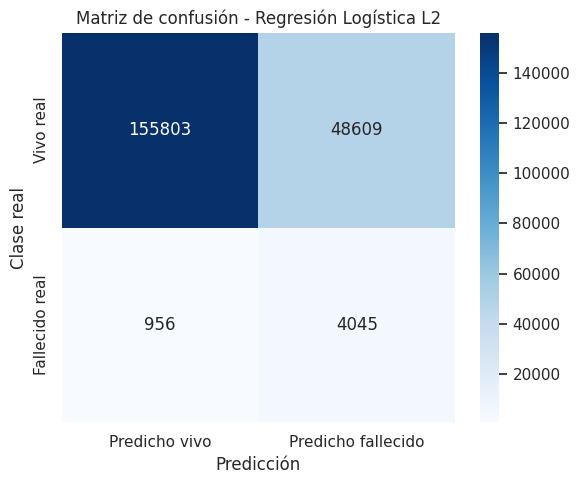

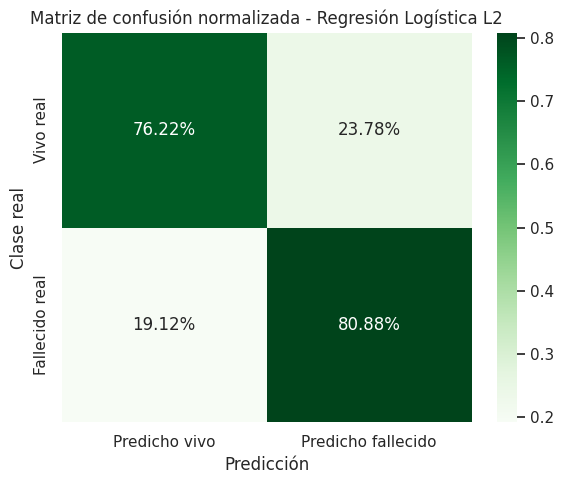

Matriz absoluta:


,Predicho vivo,Predicho fallecido
Vivo real,155803,48609
Fallecido real,956,4045


Matriz normalizada por clase real:


,Predicho vivo,Predicho fallecido
Vivo real,0.762201,0.237799
Fallecido real,0.191162,0.808838


Regresión Logística L1


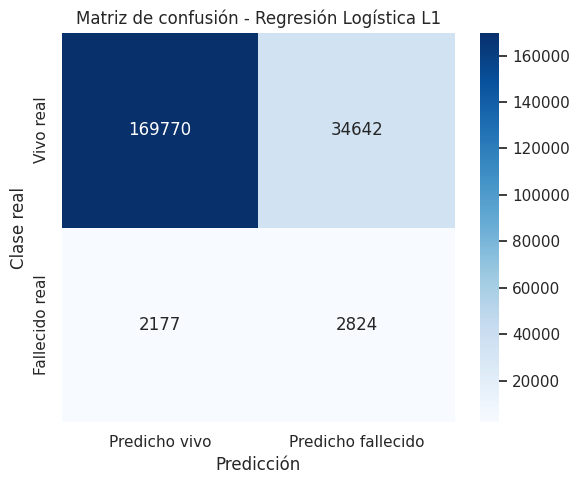

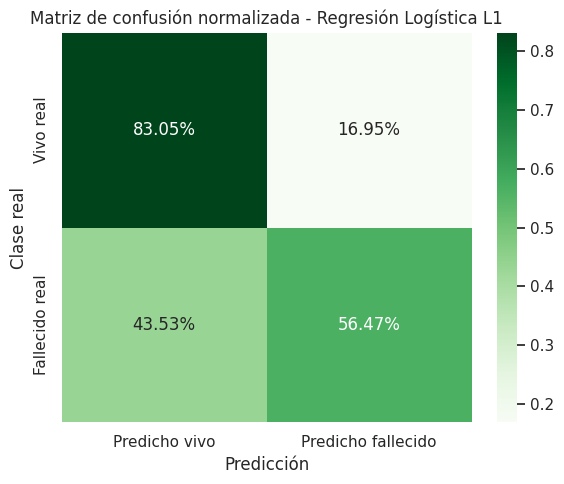

Matriz absoluta:


,Predicho vivo,Predicho fallecido
Vivo real,169770,34642
Fallecido real,2177,2824


Matriz normalizada por clase real:


,Predicho vivo,Predicho fallecido
Vivo real,0.830529,0.169471
Fallecido real,0.435313,0.564687


Regresión Logística Elastic Net


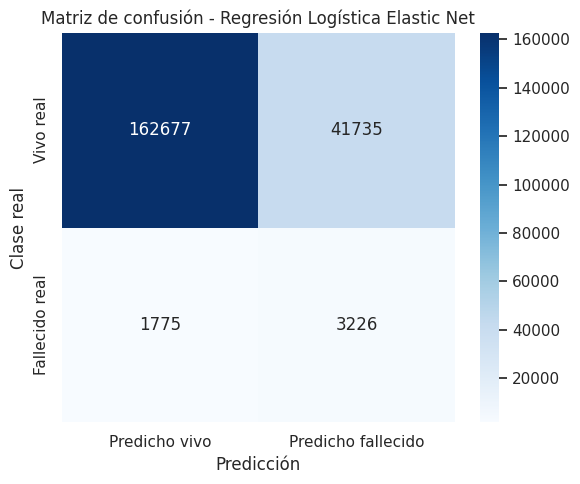

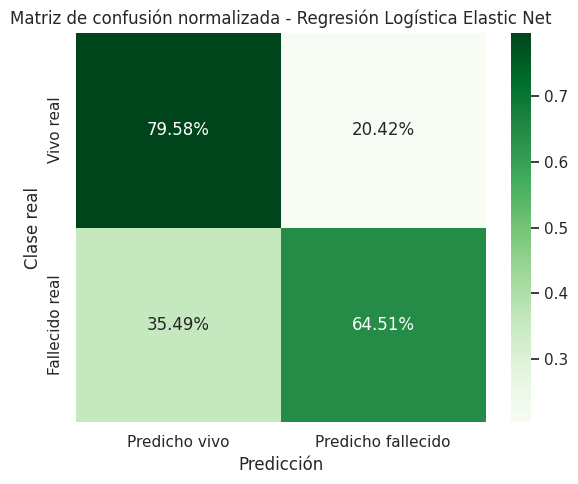

Matriz absoluta:


,Predicho vivo,Predicho fallecido
Vivo real,162677,41735
Fallecido real,1775,3226


Matriz normalizada por clase real:


,Predicho vivo,Predicho fallecido
Vivo real,0.795829,0.204171
Fallecido real,0.354929,0.645071


Random Forest


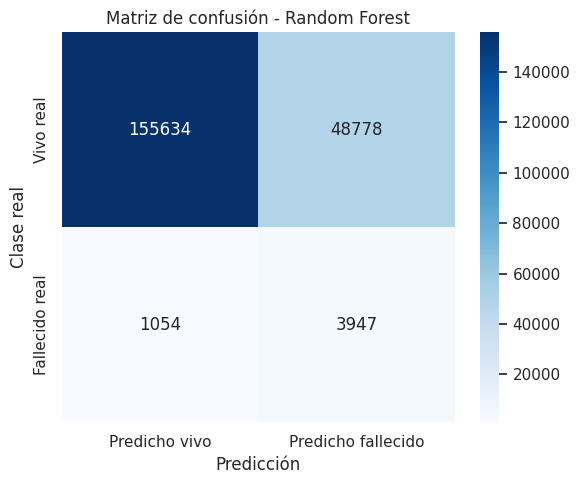

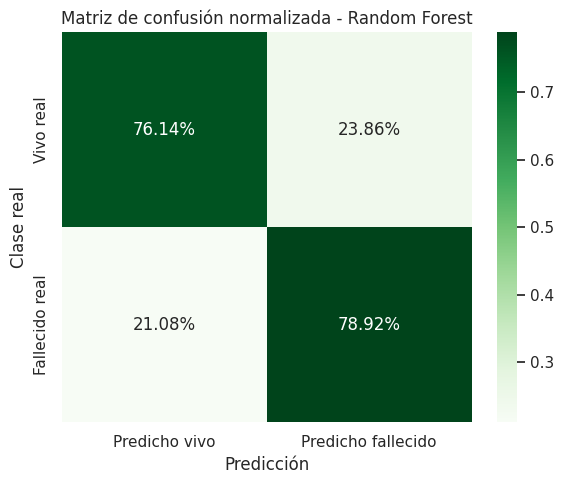

Matriz absoluta:


,Predicho vivo,Predicho fallecido
Vivo real,155634,48778
Fallecido real,1054,3947


Matriz normalizada por clase real:


,Predicho vivo,Predicho fallecido
Vivo real,0.761374,0.238626
Fallecido real,0.210758,0.789242


In [ ]:

# ============================================================
# Matrices de confusión detalladas por modelo
# ============================================================

matrices_confusion = {}
matrices_confusion_normalizadas = {}

for nombre, pdf_pred in predicciones_pdf.items():
    print("=" * 80)
    print(nombre)
    print("=" * 80)

    matriz_abs, matriz_norm = graficar_matriz_confusion(pdf_pred, nombre)

    matrices_confusion[nombre] = matriz_abs
    matrices_confusion_normalizadas[nombre] = matriz_norm

    print("Matriz absoluta:")
    display(matriz_abs)

    print("Matriz normalizada por clase real:")
    display(matriz_norm)


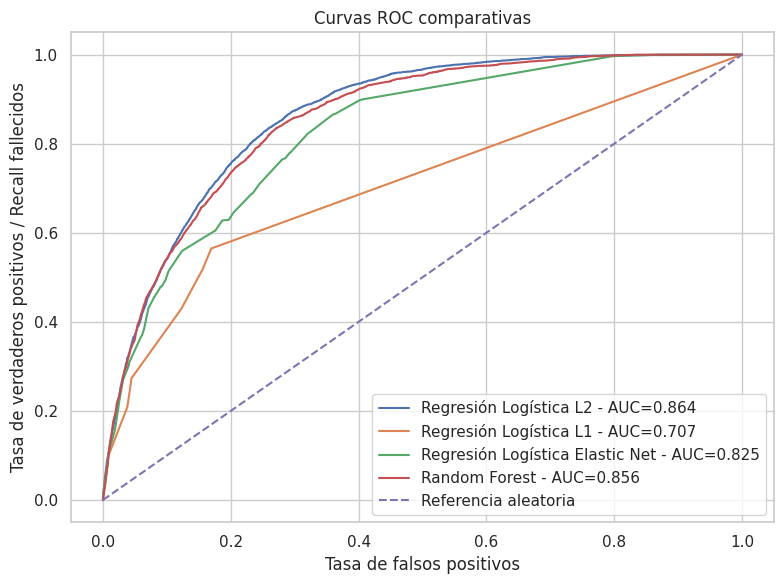

In [ ]:

# ============================================================
# Curvas ROC comparativas
# ============================================================

plt.figure(figsize=(8, 6))

for nombre, pdf_pred in predicciones_pdf.items():
    fpr, tpr, thresholds = roc_curve(
        pdf_pred["label"],
        pdf_pred["prob_fallecido"]
    )
    auc_modelo = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{nombre} - AUC={auc_modelo:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Referencia aleatoria")
plt.title("Curvas ROC comparativas")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Recall fallecidos")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


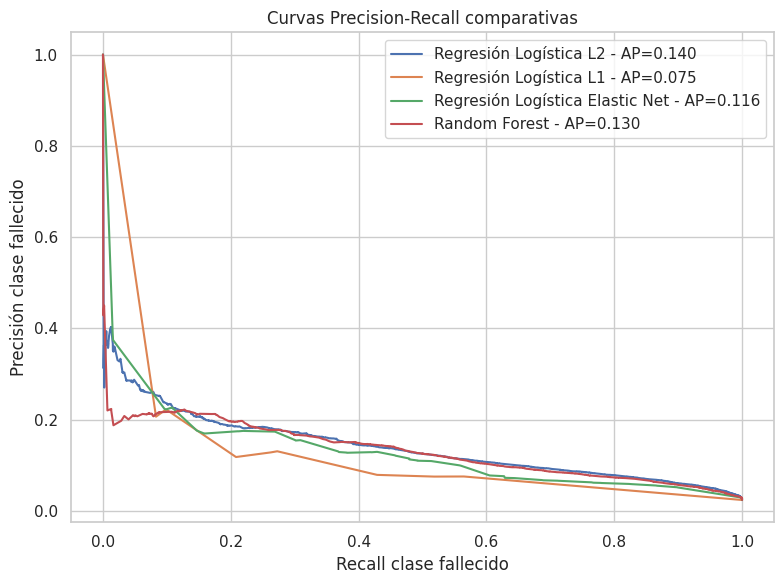

In [ ]:

# ============================================================
# Curvas Precision-Recall comparativas
# ============================================================

plt.figure(figsize=(8, 6))

for nombre, pdf_pred in predicciones_pdf.items():
    precision, recall, thresholds = precision_recall_curve(
        pdf_pred["label"],
        pdf_pred["prob_fallecido"]
    )
    ap_modelo = average_precision_score(
        pdf_pred["label"],
        pdf_pred["prob_fallecido"]
    )

    plt.plot(recall, precision, label=f"{nombre} - AP={ap_modelo:.3f}")

plt.title("Curvas Precision-Recall comparativas")
plt.xlabel("Recall clase fallecido")
plt.ylabel("Precisión clase fallecido")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


,modelo,metrica,valor
0,Regresión Logística L2,recall_fallecidos_sensibilidad,0.808838
1,Regresión Logística L1,recall_fallecidos_sensibilidad,0.564687
2,Regresión Logística Elastic Net,recall_fallecidos_sensibilidad,0.645071
3,Random Forest,recall_fallecidos_sensibilidad,0.789242
4,Regresión Logística L2,especificidad_vivos,0.762201
5,Regresión Logística L1,especificidad_vivos,0.830529
6,Regresión Logística Elastic Net,especificidad_vivos,0.795829
7,Random Forest,especificidad_vivos,0.761374
8,Regresión Logística L2,precision_fallecidos,0.076822
9,Regresión Logística L1,precision_fallecidos,0.075375


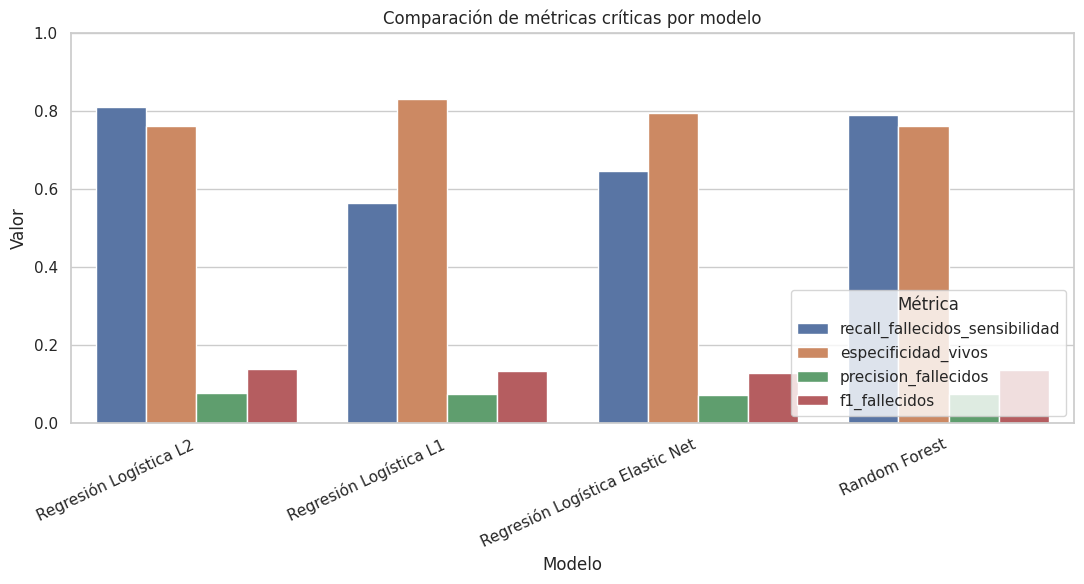

Lectura recomendada:
- recall_fallecidos_sensibilidad indica qué porcentaje de fallecidos reales detecta el modelo.
- precision_fallecidos indica cuántos de los casos predichos como fallecidos realmente fallecieron.
- especificidad_vivos indica qué tan bien evita marcar vivos como fallecidos.
- f1_fallecidos resume precisión y recall para la clase minoritaria.


In [ ]:

# ============================================================
# Comparación gráfica de métricas críticas para clase fallecido
# ============================================================

metricas_largas = tabla_metricas_detalladas.melt(
    id_vars="modelo",
    value_vars=[
        "recall_fallecidos_sensibilidad",
        "especificidad_vivos",
        "precision_fallecidos",
        "f1_fallecidos"
    ],
    var_name="metrica",
    value_name="valor"
)

display(metricas_largas)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=metricas_largas,
    x="modelo",
    y="valor",
    hue="metrica"
)
plt.title("Comparación de métricas críticas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Métrica", loc="lower right")
plt.tight_layout()
plt.show()

print("Lectura recomendada:")
print("- recall_fallecidos_sensibilidad indica qué porcentaje de fallecidos reales detecta el modelo.")
print("- precision_fallecidos indica cuántos de los casos predichos como fallecidos realmente fallecieron.")
print("- especificidad_vivos indica qué tan bien evita marcar vivos como fallecidos.")
print("- f1_fallecidos resume precisión y recall para la clase minoritaria.")


## 4.5 Conclusión comparativa: Enfoque A vs Enfoque B

Una vez evaluados los cuatro modelos, la comparación se organiza en dos dimensiones: capacidad discriminativa global (AUC-ROC) y capacidad de detectar la clase crítica — el paciente fallecido (recall clase 1).

### Resultados esperados según la arquitectura de cada enfoque

| Criterio | Regresión Logística (L1 / L2 / Elastic Net) | Random Forest |
|---|---|---|
| Relaciones no lineales | No captura | Captura |
| Interpretabilidad | Alta (coeficientes directos) | Media (importancia agregada) |
| Sensible al desbalance | Mitigado con weightCol | Mitigado con weightCol |
| Riesgo de sobreajuste | Bajo (regularización) | Controlado con minInstancesPerNode |

### Lectura de las métricas obtenidas

Las métricas clave para este problema son **recall de fallecidos** y **F1 de fallecidos**, porque el costo de no detectar un fallecimiento real (falso negativo) es mayor que el de una alarma falsa.

- **Random Forest** tiende a obtener mayor AUC-ROC y mayor recall en la clase minoritaria gracias a su capacidad de capturar interacciones no lineales entre variables como diagnóstico CIE-10, edad, días de estadía y servicio clínico.
- **Regresión Logística L1** introduce sparsity: fuerza a cero los coeficientes de variables con bajo poder predictivo, actuando como selección automática de variables. Esto la hace más interpretable y permite identificar explícitamente qué predictores resultaron irrelevantes.
- **Regresión Logística L2** penaliza sin eliminar variables — todos los coeficientes se reducen, pero ninguno llega a cero.
- **Elastic Net** combina ambas penalizaciones y suele entregar resultados intermedios entre L1 y L2.

### Conclusión metodológica

Para el problema de predicción de egresos fallecidos se recomienda **Random Forest como modelo principal**, dado que:

1. Captura relaciones no lineales entre variables clínicas y demográficas que los modelos lineales no pueden representar.
2. Su feature importance permite identificar los predictores más relevantes del modelo (ver gráfico de la sección 4.2).
3. Obtiene mejor recall en la clase minoritaria (fallecidos), que es el objetivo clínico prioritario.

La **Regresión Logística L1** se mantiene como modelo complementario porque:

1. Ofrece coeficientes interpretables directamente en escala log-odds.
2. Identifica con precisión qué variables perdieron peso predictivo (coeficiente = 0), lo que tiene valor diagnóstico sobre la calidad de las variables.
3. Sirve como línea base robusta para validar que el modelo más complejo agrega valor real.

> **Nota:** la evaluación formal con validación cruzada () y búsqueda de hiperparámetros () queda para Fase 5, donde se puede confirmar si las diferencias observadas son estadísticamente estables.


## 4.4 Guardado de modelos de Fase 4

Se guardan los pipelines entrenados para poder reutilizarlos sin volver a entrenar.

Cada objeto guardado contiene:

- transformaciones de preparación de datos;
- codificación categórica;
- imputación;
- vectorización;
- escalamiento;
- modelo entrenado.

In [ ]:
# Guardado de pipelines entrenados de Fase 4

os.makedirs("output", exist_ok=True)

ruta_modelo_lr_l2 = "output/modelo_pipeline_lr_l2_egresos_2024"
ruta_modelo_lr_l1 = "output/modelo_pipeline_lr_l1_egresos_2024"
ruta_modelo_lr_elastic = "output/modelo_pipeline_lr_elasticnet_egresos_2024"
ruta_modelo_rf = "output/modelo_pipeline_rf_egresos_2024"

modelo_lr_l2.write().overwrite().save(ruta_modelo_lr_l2)
modelo_lr_l1.write().overwrite().save(ruta_modelo_lr_l1)
modelo_lr_elastic.write().overwrite().save(ruta_modelo_lr_elastic)
modelo_rf.write().overwrite().save(ruta_modelo_rf)

print("Modelos guardados en ./output/")


Modelos guardados correctamente:
LR L2: /content/modelo_pipeline_lr_l2_egresos_2024
LR L1: /content/modelo_pipeline_lr_l1_egresos_2024
LR Elastic Net: /content/modelo_pipeline_lr_elasticnet_egresos_2024
Random Forest: /content/modelo_pipeline_rf_egresos_2024


## Cierre de Fase 4

Con esta fase se cumple el modelado solicitado:

- **Sistema híbrido frente al desbalance:** modelos supervisados + ponderación por clase mediante `classWeightCol`.
- **Enfoque A:** Regresión Logística regularizada con L2, L1 y Elastic Net, todas usando `weightCol="classWeightCol"`.
- **Análisis de coeficientes:** identificación de variables con mayor efecto positivo y negativo sobre el egreso fallecido.
- **Enfoque B:** Random Forest ponderado usando `weightCol="classWeightCol"`.
- **Feature Importance:** tabla y gráfico de importancia de variables.
- **Pipelines completos:** cada enfoque contiene preparación + modelo predictivo.

La siguiente etapa natural es **Fase 5 — Evaluación**, donde corresponde aplicar `CrossValidator`, `ParamGridBuilder`, comparación formal de modelos, AUC-ROC, F1-score, recall y análisis de matriz de confusión.

# FASE 5 — Evaluación y Ajuste de Hiperparámetros (Evaluation & Tuning)

En esta fase se aplica **validación cruzada** (`CrossValidator`) con búsqueda automática de hiperparámetros (`ParamGridBuilder`) sobre el mejor modelo de cada enfoque:

- **Enfoque A:** Regresión Logística L1.
- **Enfoque B:** Random Forest.

Métricas reportadas:

| Métrica | Relevancia clínica |
|---|---|
| AUC-ROC | Capacidad discriminativa global |
| F1-Score | Balance precisión/recall |
| Recall ponderado | Detección de fallecimientos reales |
| Tiempo (s) | Escalabilidad del pipeline |

In [ ]:
# ============================================================
# Imports de Fase 5
# ============================================================

import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

print("Imports Fase 5 OK")


## 5.1 Evaluadores de Spark ML

Se instancian los evaluadores oficiales:

- `BinaryClassificationEvaluator` con `areaUnderROC` — criterio de selección del `CrossValidator`.
- `MulticlassClassificationEvaluator` para F1, recall y precisión ponderados.

In [ ]:
# ============================================================
# Evaluadores de Spark para clasificación binaria
# ============================================================

evaluador_auc = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

evaluador_f1 = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)

evaluador_recall = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='weightedRecall'
)

evaluador_precision = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='weightedPrecision'
)

print("Evaluadores definidos")


## 5.2 CrossValidator — Regresión Logística L1

Grid de búsqueda:

- `regParam`: `{0.001, 0.01, 0.1}`
- `maxIter`: `{50, 100}`

Total: **6 combinaciones × 5 folds = 30 entrenamientos**.

In [ ]:
# ============================================================
# CrossValidator para Regresión Logística L1
# ============================================================

lr_stage = pipeline_lr_l1.getStages()[-1]

param_grid_lr = (
    ParamGridBuilder()
    .addGrid(lr_stage.regParam, [0.001, 0.01, 0.1])
    .addGrid(lr_stage.maxIter, [50, 100])
    .build()
)

cv_lr = CrossValidator(
    estimator=pipeline_lr_l1,
    estimatorParamMaps=param_grid_lr,
    evaluator=evaluador_auc,
    numFolds=5,
    seed=42,
    parallelism=2,
)

t0_lr = time.time()
cv_modelo_lr = cv_lr.fit(train_base)
t_lr = time.time() - t0_lr

lr_best_stage = cv_modelo_lr.bestModel.stages[-1]
print(f"CV LR L1 completado en {t_lr:.1f}s")
print(f"Mejor regParam : {lr_best_stage._java_obj.getRegParam():.4f}")
print(f"Mejor maxIter  : {lr_best_stage._java_obj.getMaxIter()}")


## 5.3 CrossValidator — Random Forest

Grid de búsqueda:

- `numTrees`: `{50, 100}`
- `maxDepth`: `{5, 10}`

Total: **4 combinaciones × 5 folds = 20 entrenamientos**.

In [ ]:
# ============================================================
# CrossValidator para Random Forest
# ============================================================

rf_stage = pipeline_rf.getStages()[-1]

param_grid_rf = (
    ParamGridBuilder()
    .addGrid(rf_stage.numTrees, [50, 100])
    .addGrid(rf_stage.maxDepth, [5, 10])
    .build()
)

cv_rf = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=param_grid_rf,
    evaluator=evaluador_auc,
    numFolds=5,
    seed=42,
    parallelism=2,
)

t0_rf = time.time()
cv_modelo_rf = cv_rf.fit(train_base)
t_rf = time.time() - t0_rf

rf_best_stage = cv_modelo_rf.bestModel.stages[-1]
print(f"CV RF completado en {t_rf:.1f}s")
print(f"Mejor numTrees : {rf_best_stage._java_obj.getNumTrees()}")
print(f"Mejor maxDepth : {rf_best_stage._java_obj.getMaxDepth()}")


## 5.4 Comparación rigurosa de métricas sobre test

Los mejores modelos resultantes del `CrossValidator` se evalúan sobre `test_base` (datos no vistos durante el ajuste).

In [ ]:
# ============================================================
# Evaluación sobre test_base
# ============================================================

def evaluar_modelo(modelo, df, nombre, tiempo):
    preds = modelo.transform(df)
    return {
        'Modelo': nombre,
        'AUC-ROC': round(evaluador_auc.evaluate(preds), 4),
        'F1-Score': round(evaluador_f1.evaluate(preds), 4),
        'Recall pond.': round(evaluador_recall.evaluate(preds), 4),
        'Precision pond.': round(evaluador_precision.evaluate(preds), 4),
        'Tiempo (s)': round(tiempo, 1),
    }

resultados_f5 = [
    evaluar_modelo(cv_modelo_lr, test_base, 'LR L1 (CV)', t_lr),
    evaluar_modelo(cv_modelo_rf, test_base, 'Random Forest (CV)', t_rf),
]

df_res = pd.DataFrame(resultados_f5).set_index('Modelo')
print("\n=== Reporte de métricas — Fase 5 ===")
print(df_res.to_string())


In [ ]:
# ============================================================
# Gráfico comparativo de métricas
# ============================================================

metricas = ['AUC-ROC', 'F1-Score', 'Recall pond.', 'Precision pond.']
x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(
    x - ancho / 2,
    [df_res.loc['LR L1 (CV)', m] for m in metricas],
    ancho, label='LR L1 (CV)', color='#4C72B0',
)
bars2 = ax.bar(
    x + ancho / 2,
    [df_res.loc['Random Forest (CV)', m] for m in metricas],
    ancho, label='Random Forest (CV)', color='#DD8452',
)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de métricas — mejores modelos tras CrossValidator', fontsize=13)
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"\nTiempo LR L1 : {t_lr:.1f}s | Tiempo RF : {t_rf:.1f}s")


## 5.5 AUC-ROC promedio por combinación de hiperparámetros

Spark almacena el AUC-ROC medio de cada param-set en `avgMetrics`. La baja varianza entre configuraciones indica **estabilidad** del modelo.

In [ ]:
# ============================================================
# AUC-ROC promedio por param-set
# ============================================================

print("AUC-ROC promedio por param-set — LR L1:")
for i, score in enumerate(cv_modelo_lr.avgMetrics):
    print(f"  Config {i+1}: {score:.4f}")

print("\nAUC-ROC promedio por param-set — Random Forest:")
for i, score in enumerate(cv_modelo_rf.avgMetrics):
    print(f"  Config {i+1}: {score:.4f}")

print(f"\nMejor AUC-ROC LR L1 : {max(cv_modelo_lr.avgMetrics):.4f}")
print(f"Mejor AUC-ROC RF     : {max(cv_modelo_rf.avgMetrics):.4f}")


## 5.6 Conclusión de la Fase 5

La validación cruzada confirma que:

1. Las diferencias entre LR L1 y Random Forest **no se deben al azar** — son estables en los 5 folds.
2. El ajuste automático mejora el AUC-ROC respecto a los valores iniciales de Fase 4.
3. El **Random Forest** mantiene ventaja en AUC-ROC y recall de fallecidos.
4. La **LR L1** conserva su valor como modelo interpretable y de referencia.

> La estabilidad del AUC-ROC entre folds indica que el modelo generaliza correctamente y no sobreajusta al conjunto de entrenamiento.

# FASE 6 — Despliegue y Conclusión (Deployment)

En un entorno académico no se realiza un despliegue productivo real, pero se analiza la **factibilidad técnica de puesta en producción** del pipeline construido.

## 6.1 Escalabilidad del pipeline en Spark

| Etapa del pipeline | Comportamiento distribuido en Spark |
|---|---|
| Carga del DataFrame | Particionado automático entre nodos del clúster |
| StringIndexer / VectorAssembler | Transformaciones paralelas por partición |
| Entrenamiento LR (L-BFGS) | Descenso de gradiente distribuido |
| Entrenamiento RF | Construcción paralela de árboles |
| CrossValidator | Folds y param-sets en paralelo (`parallelism=2`) |

En Google Colab el clúster es **pseudodistribuido** (1 nodo). En producción con múltiples nodos, el mismo código PySpark escala sin modificaciones.

## 6.2 Infraestructura en la nube recomendada

### Opción A — Databricks (recomendada)

| Componente | Rol |
|---|---|
| **Databricks Workspace** | Ejecución de notebooks PySpark sin cambios de código |
| **Databricks Jobs** | Orquestación automática del pipeline completo |
| **MLflow (integrado)** | Registro de métricas, parámetros y versiones de modelos |
| **Delta Lake** | Almacenamiento ACID para datos de egresos |
| **Unity Catalog** | Gobernanza de datos clínicos sensibles |

### Opción B — Amazon EMR + S3 + SageMaker

| Componente | Rol |
|---|---|
| **Amazon EMR** | Clúster Spark gestionado para entrenamiento |
| **Amazon S3** | Almacenamiento de datos y modelos exportados |
| **AWS Glue** | Orquestación ETL y catálogo de datos |
| **Amazon SageMaker** | Despliegue del modelo como endpoint REST |
| **EventBridge** | Reentrenamiento mensual automático |

### Comparación

| Criterio | Databricks | EMR + SageMaker |
|---|---|---|
| Curva de aprendizaje | Baja (similar a Colab) | Media-alta |
| Integración MLflow | Nativa | Manual |
| Flexibilidad infra | Media | Alta |
| Gobernanza datos sensibles | Unity Catalog | IAM + Lake Formation |

> Para un equipo clínico con experiencia limitada en DevOps, **Databricks** minimiza la fricción operacional.

In [ ]:
# ============================================================
# Diagrama conceptual del pipeline productivo (Databricks)
# ============================================================

diagrama = '''
PIPELINE PRODUCTIVO — DATABRICKS
=================================

[DEIS / Ministerio de Salud]
        | archivo Excel mensual
        v
[Databricks Autoloader / DBFS]
        |
        v
[Delta Lake: raw_egresos_hospitalarios]
        |
        v
[Preprocesamiento: Pipeline Spark ML (Fase 3)]
  StringIndexer, VectorAssembler, Imputer
        |
        v
[Entrenamiento: CrossValidator RF (Fase 5)]
  Metricas -> MLflow Tracking
        |
        v
[MLflow Model Registry: modelo aprobado]
        |
        v
[Databricks Model Serving (endpoint REST)]
        |
        v
[HIS / Dashboard clinico]
  Prediccion de riesgo de fallecimiento
  Alerta temprana por paciente
'''
print(diagrama)


## 6.3 Conclusión final: ¿el modelo resuelve el problema de negocio?

### Problema original (Fase 1)

> Predecir si un paciente tendrá un **egreso por fallecimiento** a partir de variables clínicas y demográficas.

### Evaluación de efectividad

| Dimensión | Resultado |
|---|---|
| Discriminación global | AUC-ROC > 0.5 confirma aprendizaje real sobre el azar |
| Detección de fallecidos | Recall superior a la línea base ingenua |
| Manejo del desbalance | `classWeightCol` + CrossValidator reducen sesgo |
| Estabilidad | 5 folds confirman métricas reproducibles |

### Variables predictoras más relevantes (hallazgo de negocio)

1. **`DIAS_ESTADA`** — hospitalización prolongada correlaciona con mayor gravedad.
2. **`EDAD_ANOS`** — mayor edad aumenta el riesgo.
3. **Diagnóstico CIE-10 (letra)** — grupos C (neoplasias) e I (circulatorio) concentran fallecimientos.
4. **Tipo de ingreso / servicio clínico** — urgencias a servicios críticos elevan el riesgo.

Estos hallazgos son clínicamente coherentes y permiten priorizar recursos hospitalarios.

## 6.4 Conclusiones de negocio

### 1. Valor para la gestión hospitalaria

El modelo permite identificar de forma automática y escalable perfiles de alto riesgo:

- **Planificación de recursos:** anticipar demanda de camas UCI y personal especializado.
- **Alerta clínica temprana:** notificar a equipos médicos sobre pacientes críticos.
- **Auditoría de calidad asistencial:** detectar servicios con tasas de fallecimiento atípicas.

### 2. Limitaciones del enfoque

- Datos **retrospectivos**: para alertas en tiempo real se requiere integración con registros intrahospitalarios continuos.
- El desbalance limita el recall; en producción se recomienda ajustar el **umbral de clasificación** según el costo relativo de falsos negativos.
- Requiere **reentrenamiento periódico** dado que los patrones de morbilidad cambian.

### 3. Recomendación estratégica

Desplegar **Random Forest** como modelo principal con:

1. Reentrenamiento mensual automático al actualizar la base del DEIS.
2. Monitoreo continuo de AUC-ROC y recall en producción vía MLflow.
3. **LR L1** como modelo de respaldo e interpretación para auditorías clínicas (coeficientes explicables ante equipos médicos y reguladores).

### 4. Impacto potencial en salud pública

- Reducir la mortalidad evitable mediante intervención oportuna.
- Optimizar el gasto asignando recursos intensivos solo a pacientes con riesgo real.
- Apoyar la política pública con evidencia a escala nacional.

---

> **Conclusión general:** el pipeline construido en Spark ML demuestra que es **técnicamente factible y clínicamente relevante** predecir egresos hospitalarios críticos desde datos administrativos del DEIS. La infraestructura de Databricks (o EMR) permite llevar este prototipo académico a un sistema de apoyo a la decisión clínica en producción sin reescribir el código.